In [15]:
import pandas as pd
from prophet import Prophet
import holidays
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


Categorías válidas: 58


20:29:47 - cmdstanpy - INFO - Chain [1] start processing
20:29:48 - cmdstanpy - INFO - Chain [1] done processing
20:29:48 - cmdstanpy - INFO - Chain [1] start processing
20:29:49 - cmdstanpy - INFO - Chain [1] done processing
20:29:49 - cmdstanpy - INFO - Chain [1] start processing
20:29:50 - cmdstanpy - INFO - Chain [1] done processing
20:29:51 - cmdstanpy - INFO - Chain [1] start processing
20:29:51 - cmdstanpy - INFO - Chain [1] done processing
20:29:52 - cmdstanpy - INFO - Chain [1] start processing
20:29:52 - cmdstanpy - INFO - Chain [1] done processing
20:29:53 - cmdstanpy - INFO - Chain [1] start processing
20:29:53 - cmdstanpy - INFO - Chain [1] done processing
20:29:54 - cmdstanpy - INFO - Chain [1] start processing
20:29:55 - cmdstanpy - INFO - Chain [1] done processing
20:29:55 - cmdstanpy - INFO - Chain [1] start processing
20:29:56 - cmdstanpy - INFO - Chain [1] done processing
20:29:57 - cmdstanpy - INFO - Chain [1] start processing
20:29:57 - cmdstanpy - INFO - Chain [1]

[furniture_bedroom] Sin solapamiento test/predicción, se omite métricas.


20:30:28 - cmdstanpy - INFO - Chain [1] start processing
20:30:29 - cmdstanpy - INFO - Chain [1] done processing
20:30:29 - cmdstanpy - INFO - Chain [1] start processing
20:30:30 - cmdstanpy - INFO - Chain [1] done processing
20:30:31 - cmdstanpy - INFO - Chain [1] start processing
20:30:31 - cmdstanpy - INFO - Chain [1] done processing
20:30:32 - cmdstanpy - INFO - Chain [1] start processing
20:30:33 - cmdstanpy - INFO - Chain [1] done processing
20:30:33 - cmdstanpy - INFO - Chain [1] start processing
20:30:34 - cmdstanpy - INFO - Chain [1] done processing
20:30:35 - cmdstanpy - INFO - Chain [1] start processing
20:30:35 - cmdstanpy - INFO - Chain [1] done processing
20:30:36 - cmdstanpy - INFO - Chain [1] start processing
20:30:36 - cmdstanpy - INFO - Chain [1] done processing
20:30:37 - cmdstanpy - INFO - Chain [1] start processing
20:30:38 - cmdstanpy - INFO - Chain [1] done processing
20:30:38 - cmdstanpy - INFO - Chain [1] start processing
20:30:39 - cmdstanpy - INFO - Chain [1]

,MAE,RMSE,MAPE (%)
category,,,
agro_industry_and_commerce,4.376239,4.813290,341.040705
air_conditioning,0.649959,1.022980,28.295896
art,0.622408,0.802265,37.888339
audio,0.864928,1.057409,50.015455
auto,6.252094,6.871354,132.649851
baby,4.380136,5.262797,209.334441
bed_bath_table,7.188414,8.383957,76.048440
books_general_interest,1.086929,1.163072,79.212120
books_imported,2.435044,2.435044,243.504389


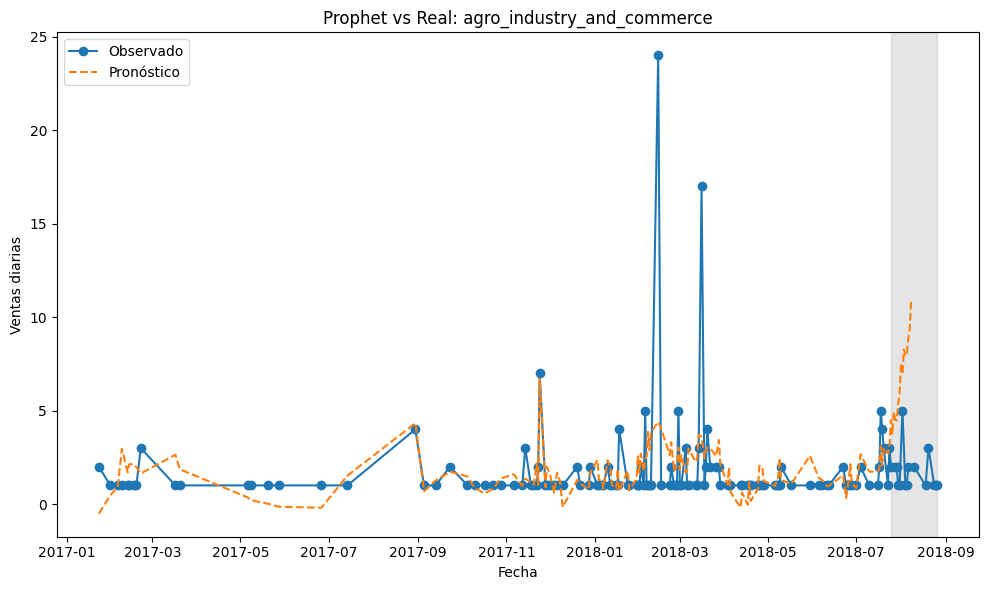

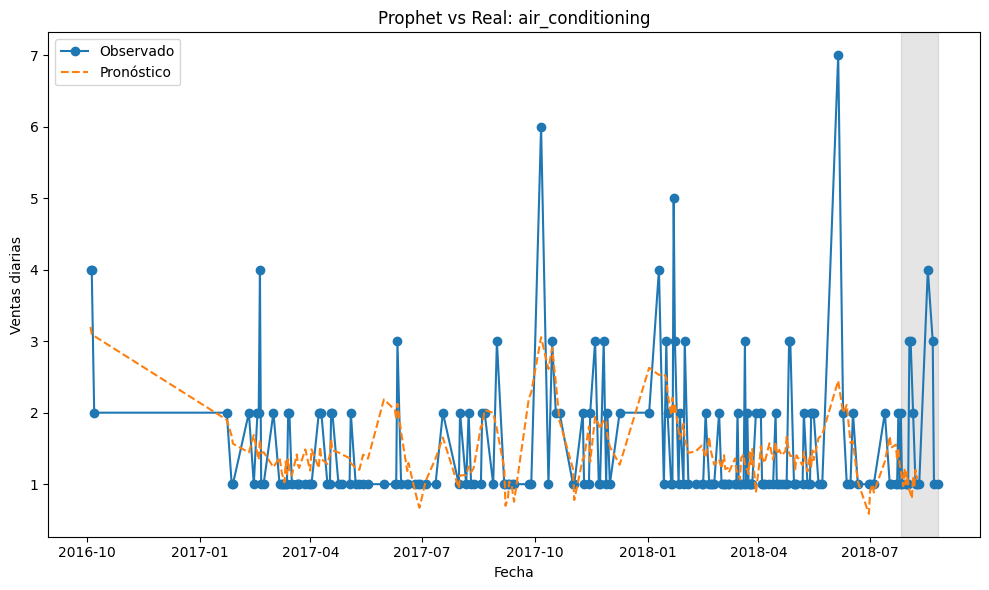

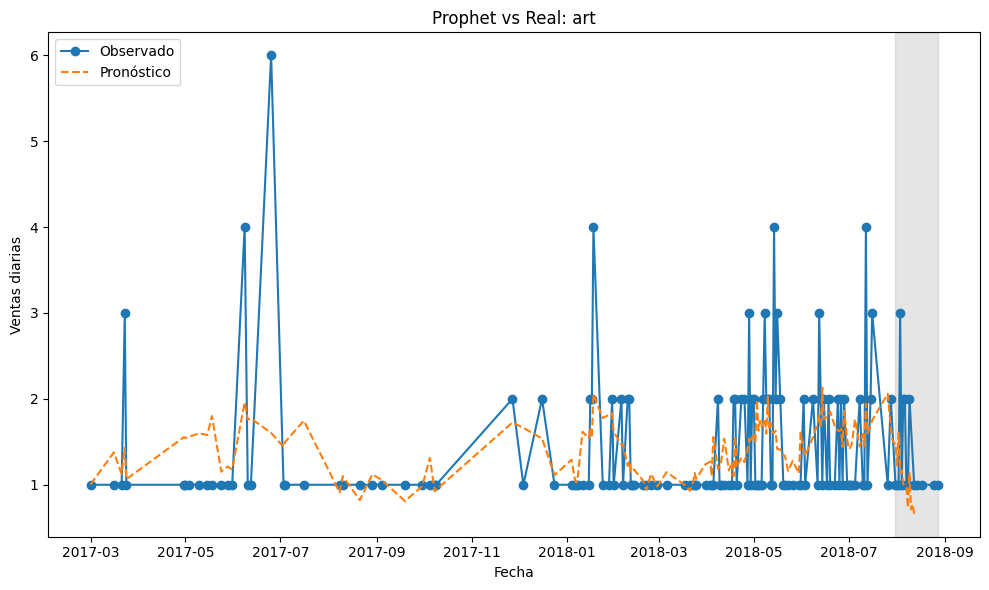

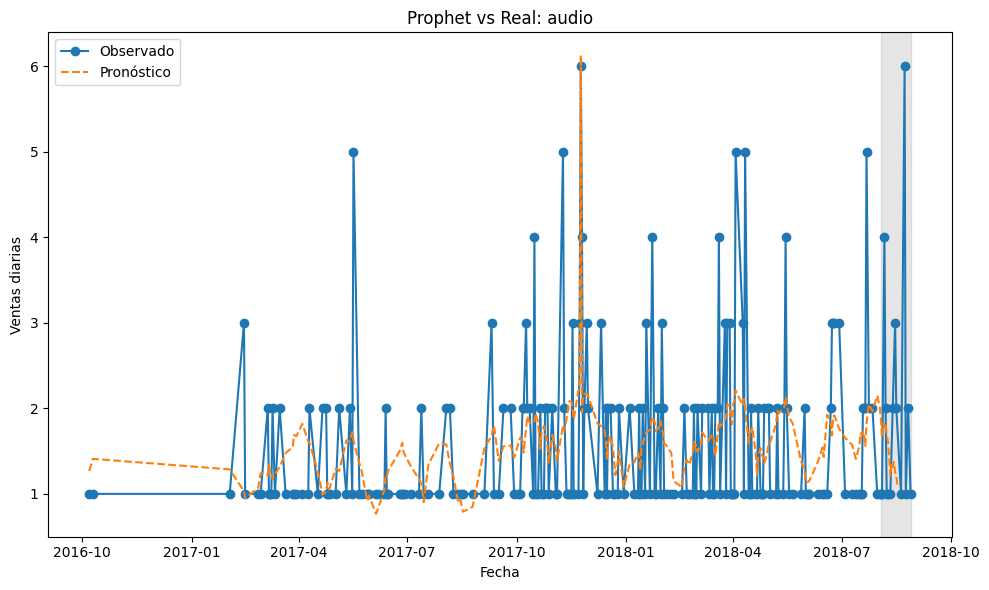

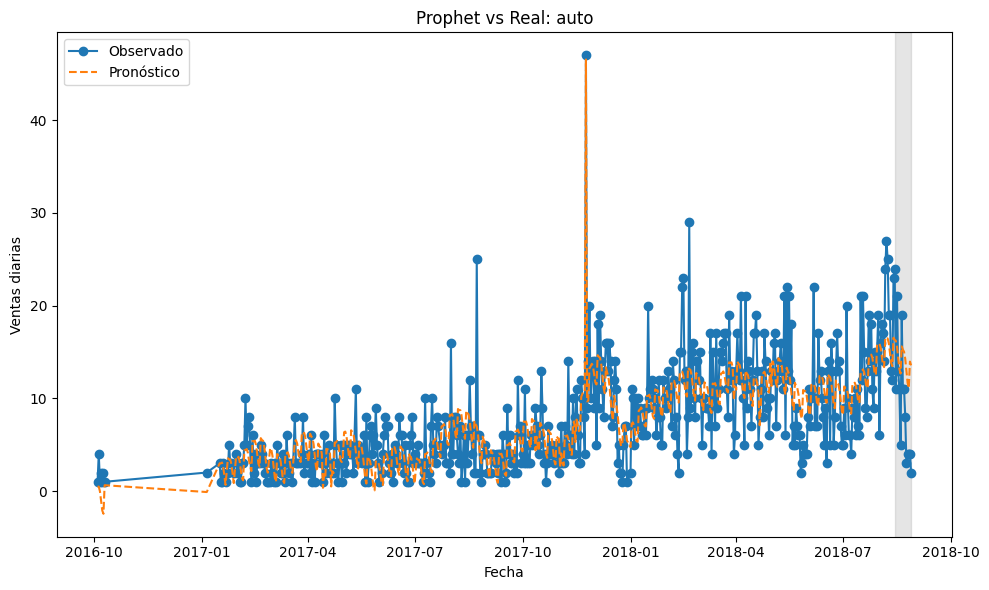

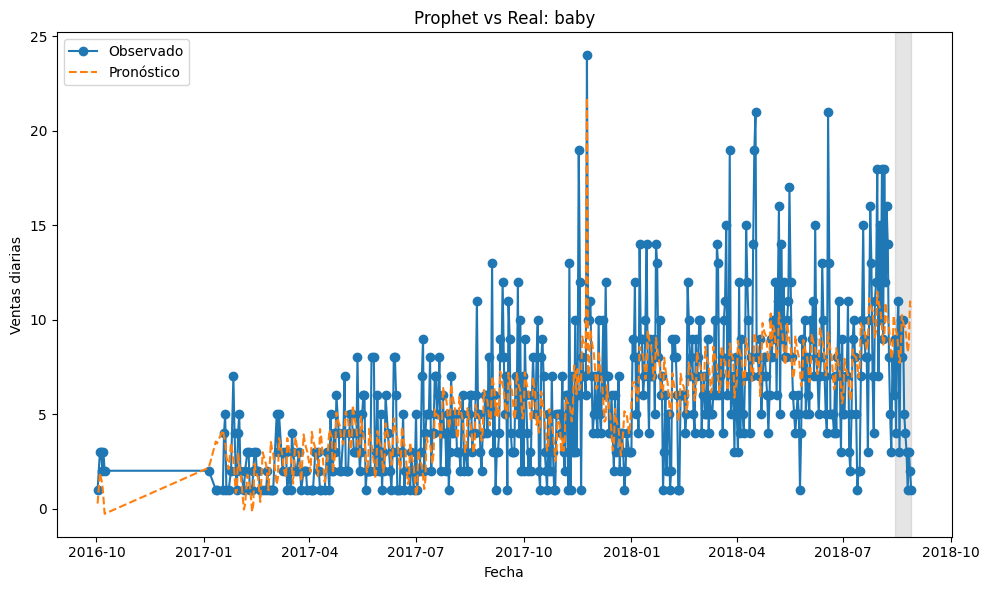

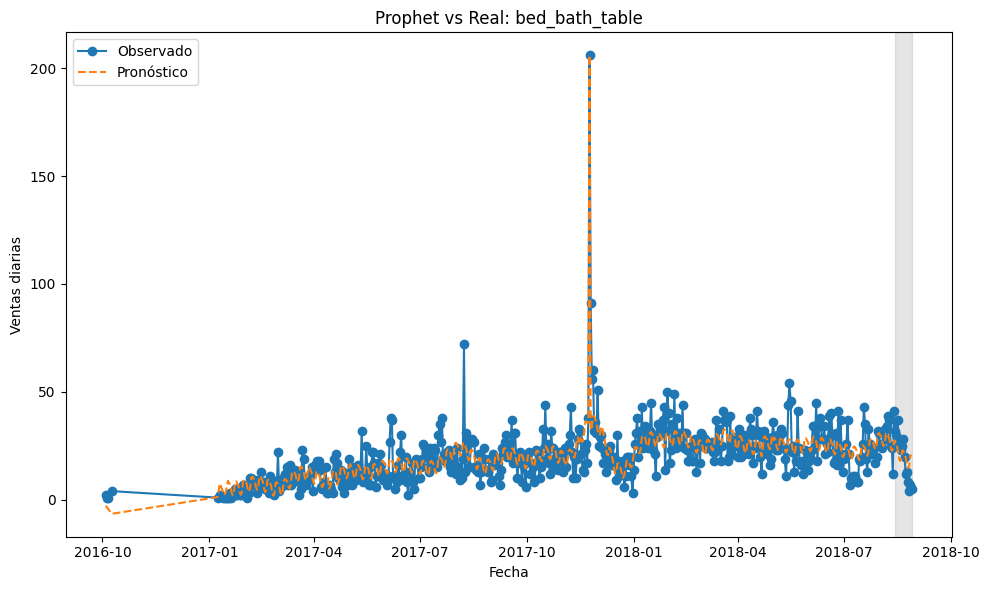

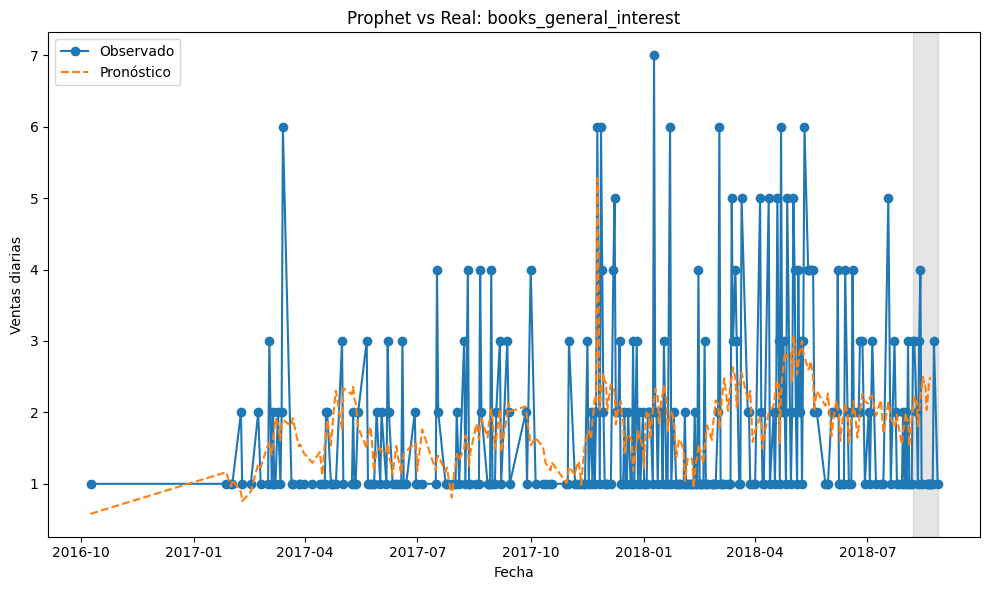

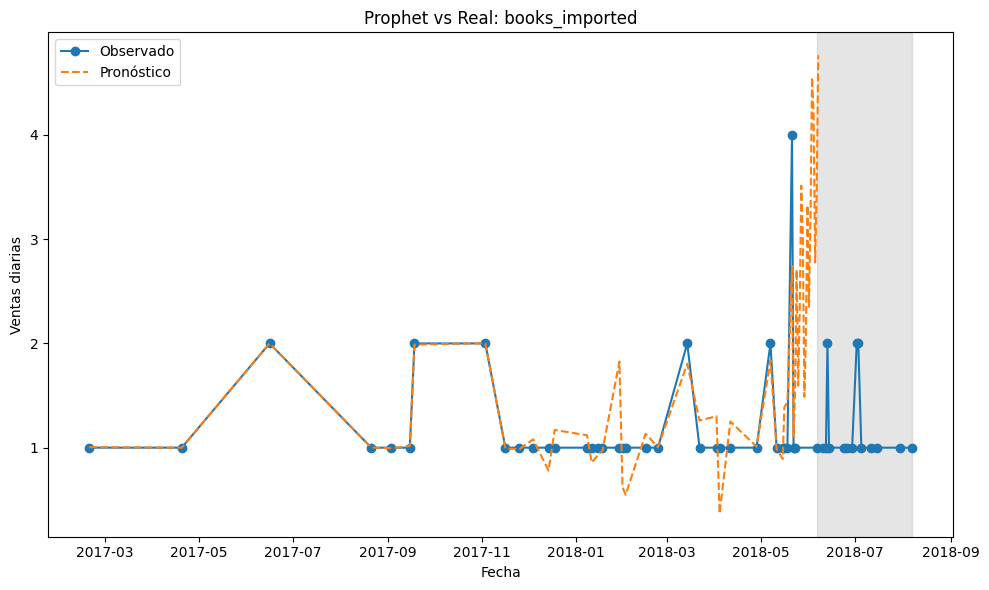

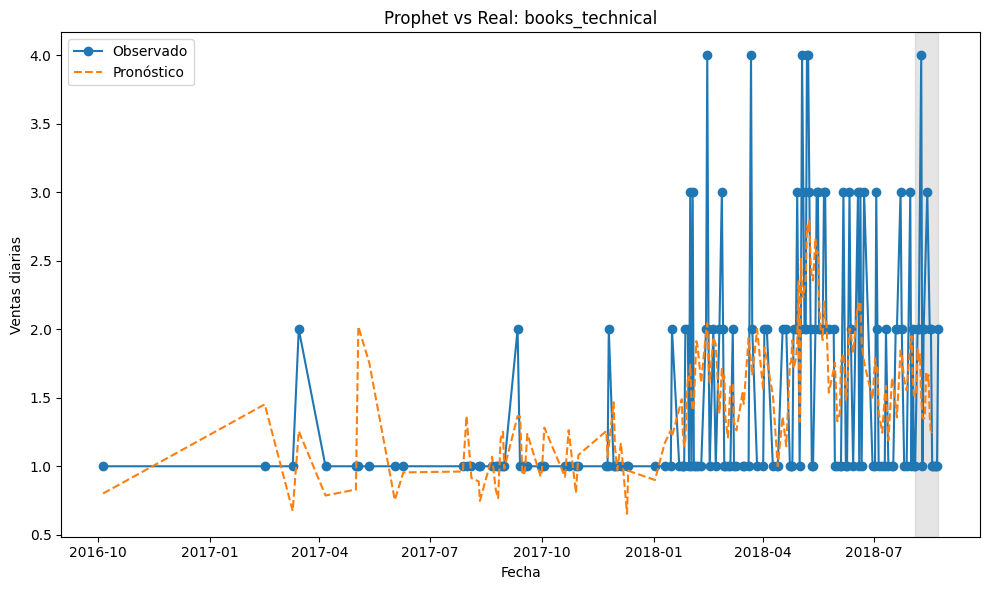

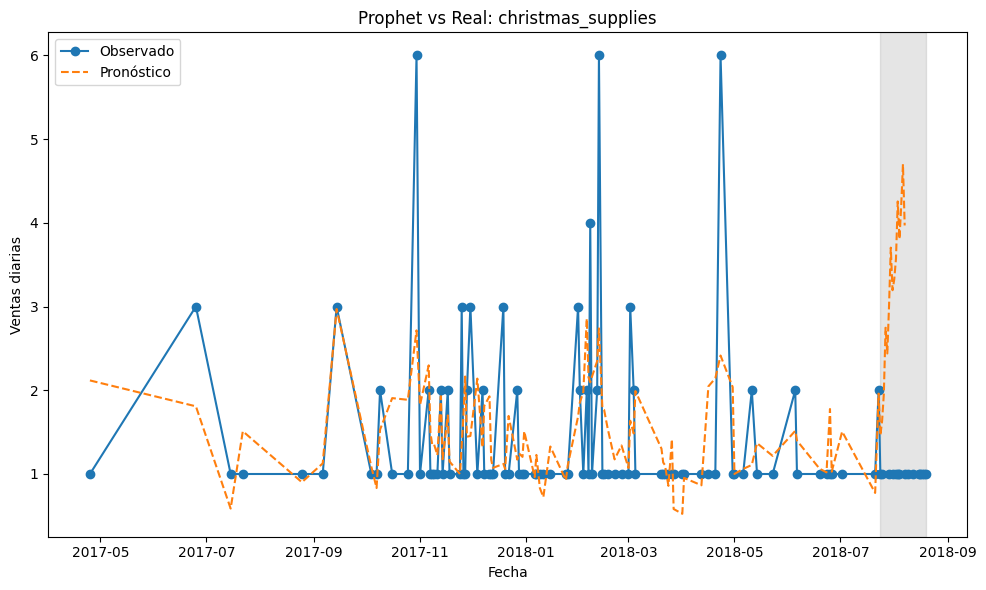

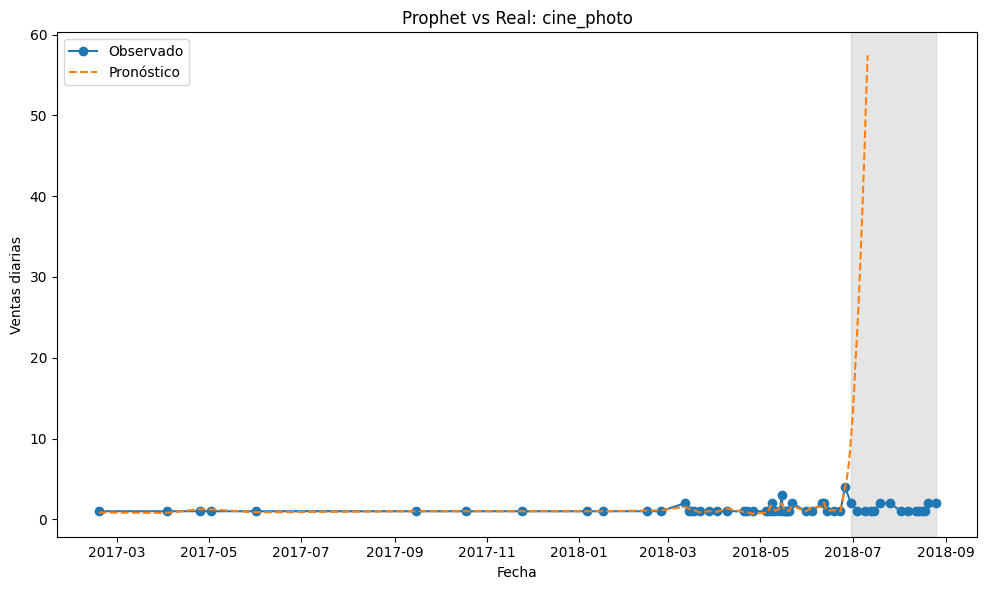

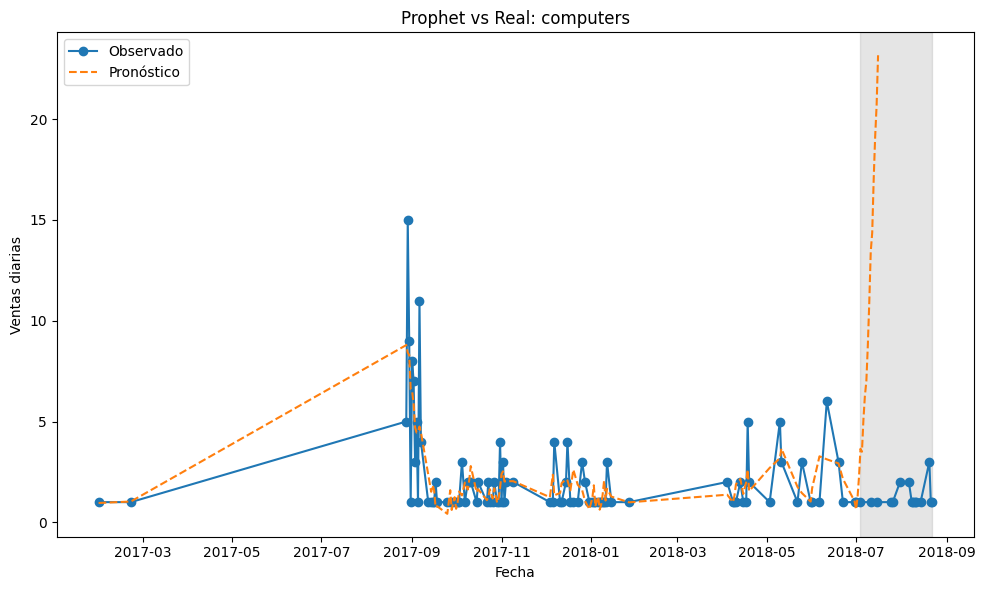

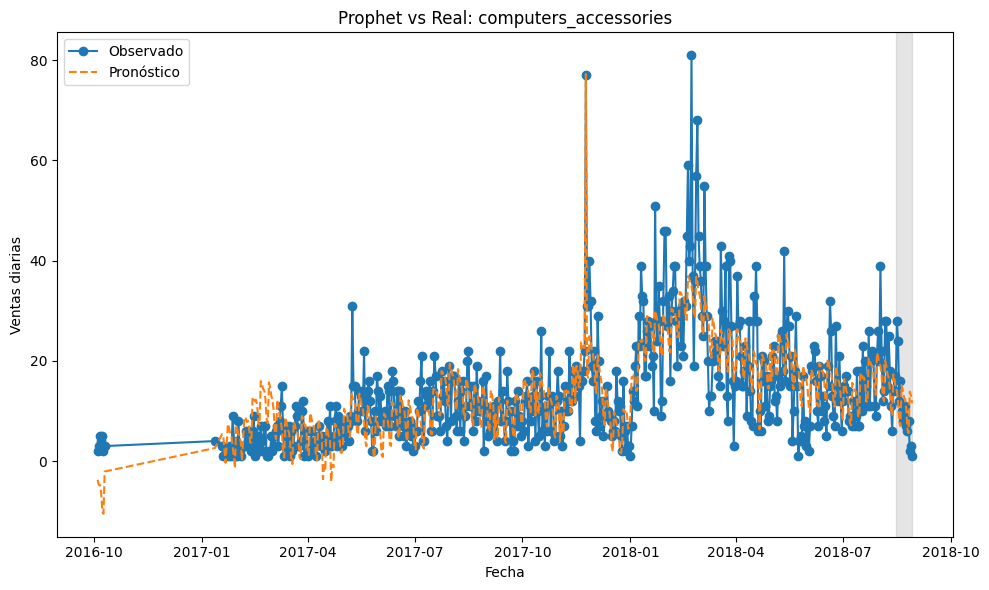

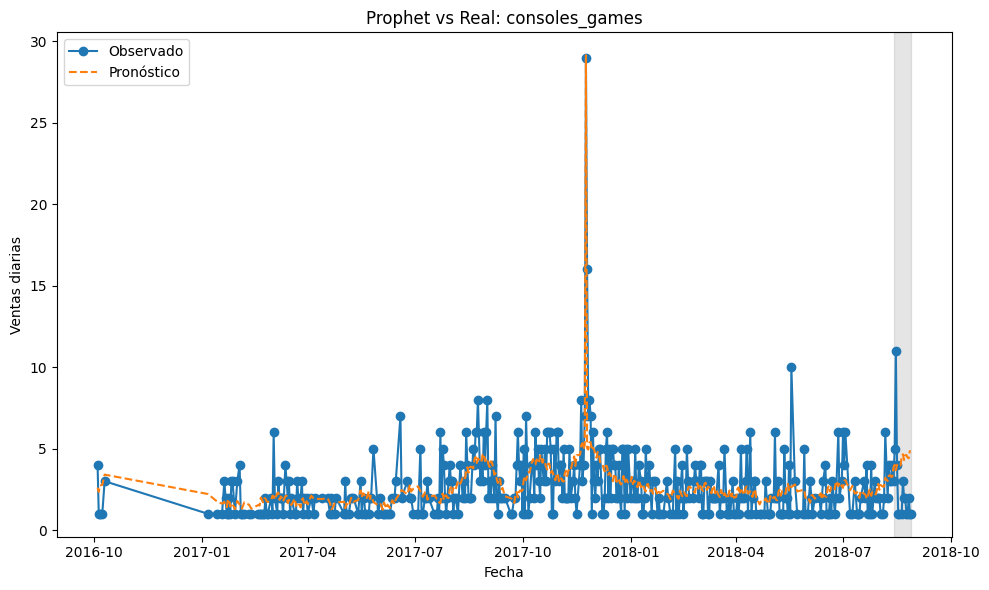

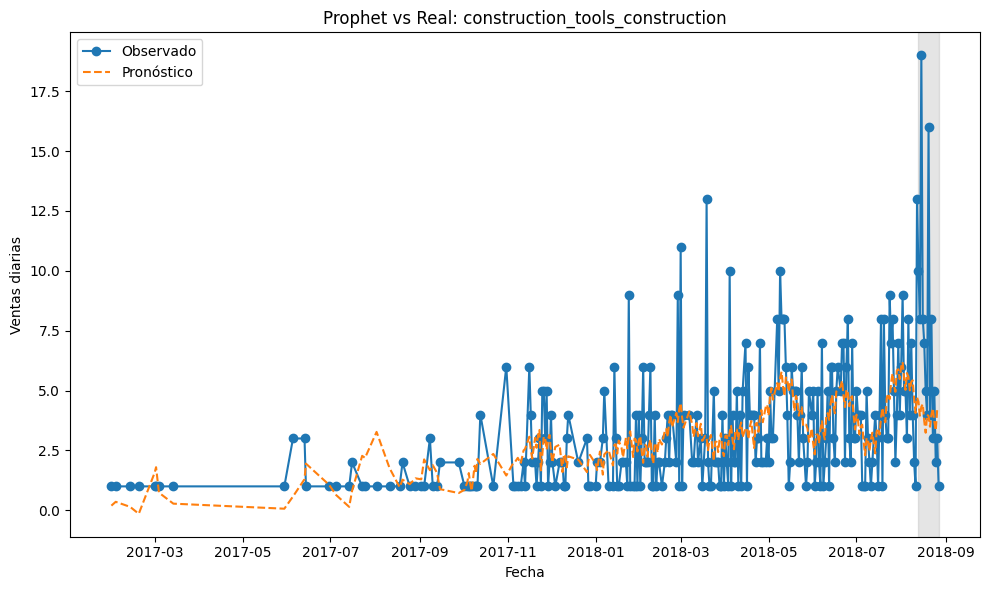

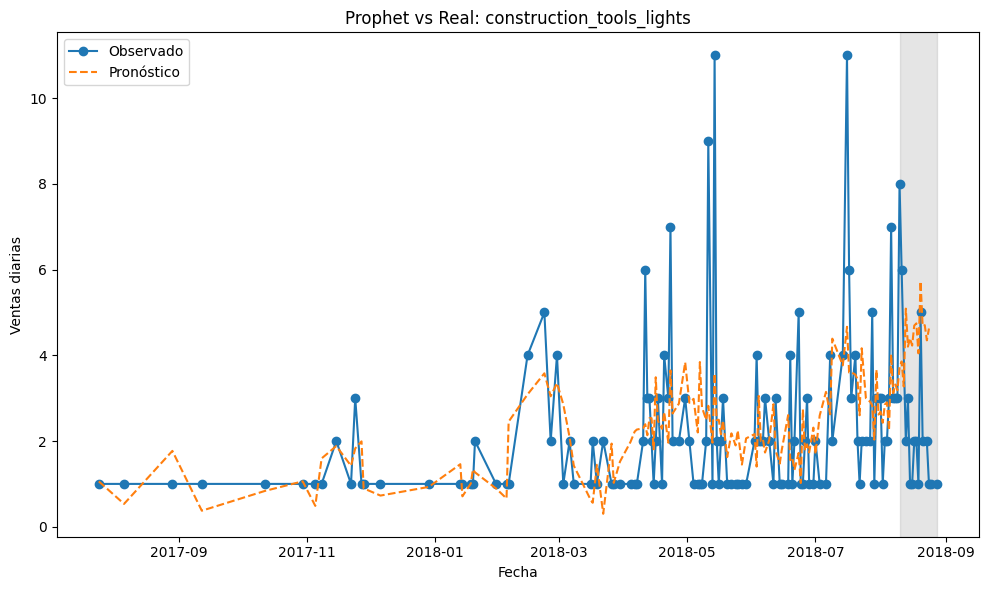

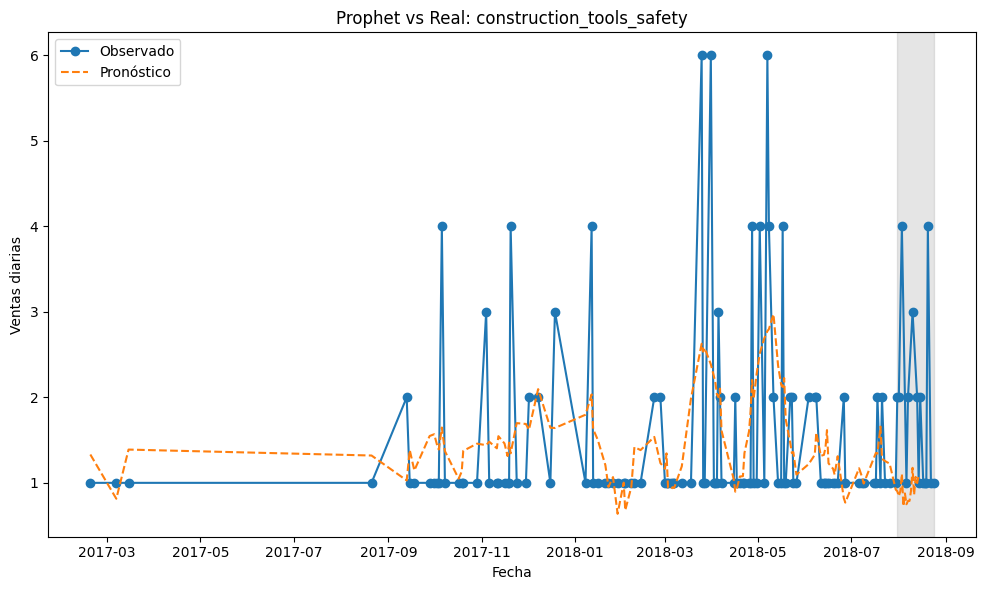

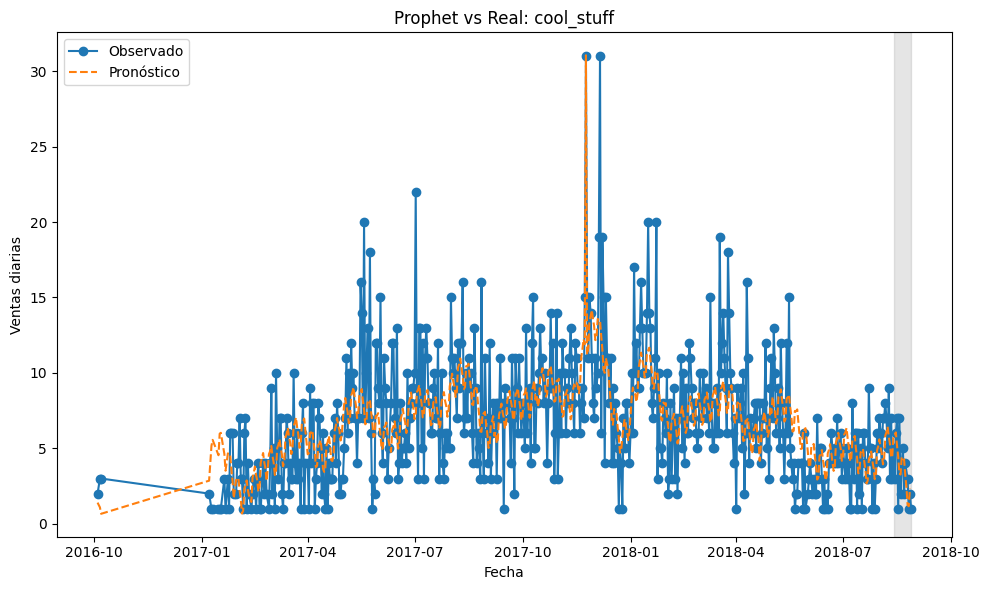

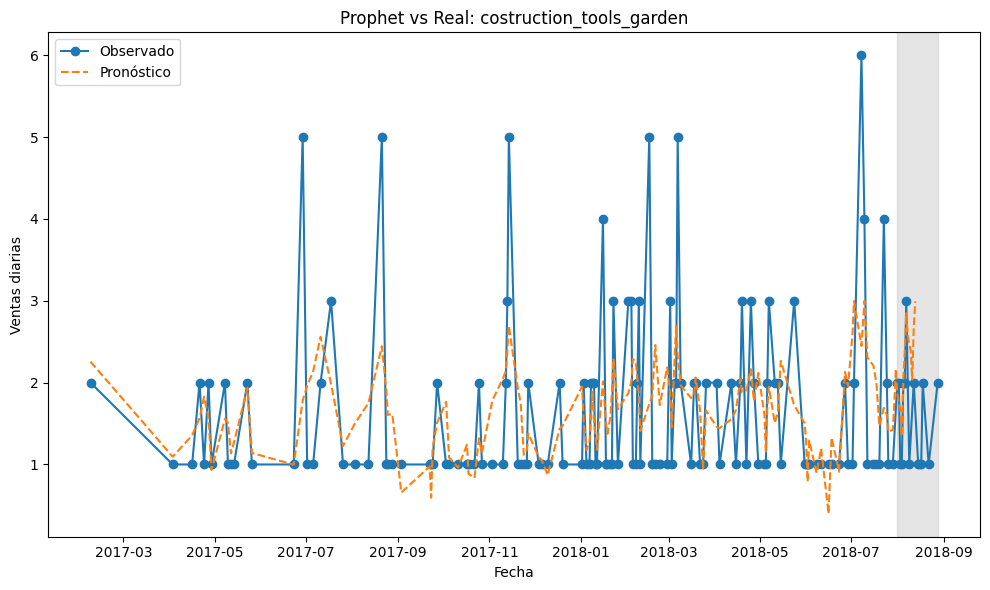

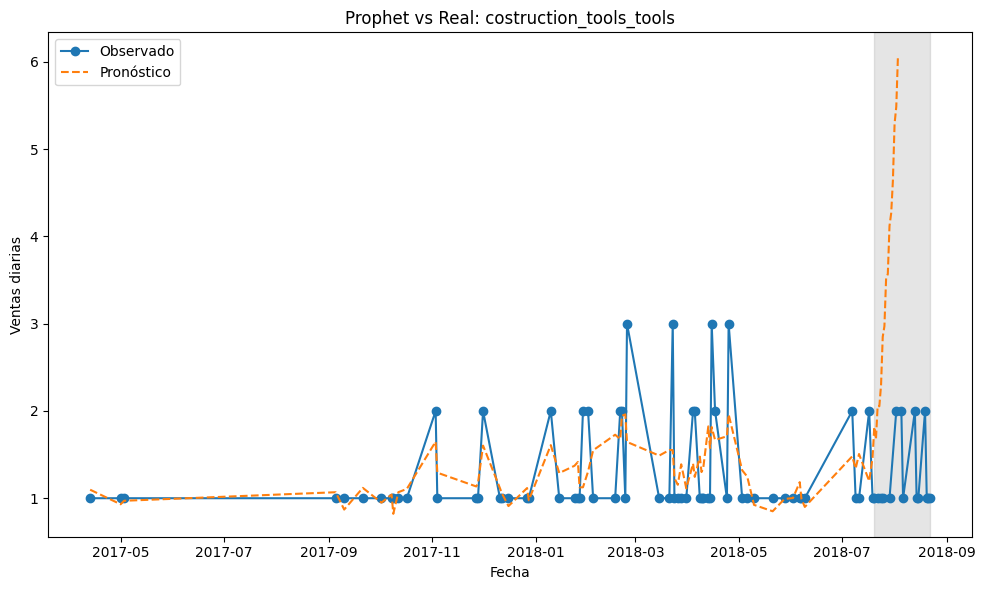

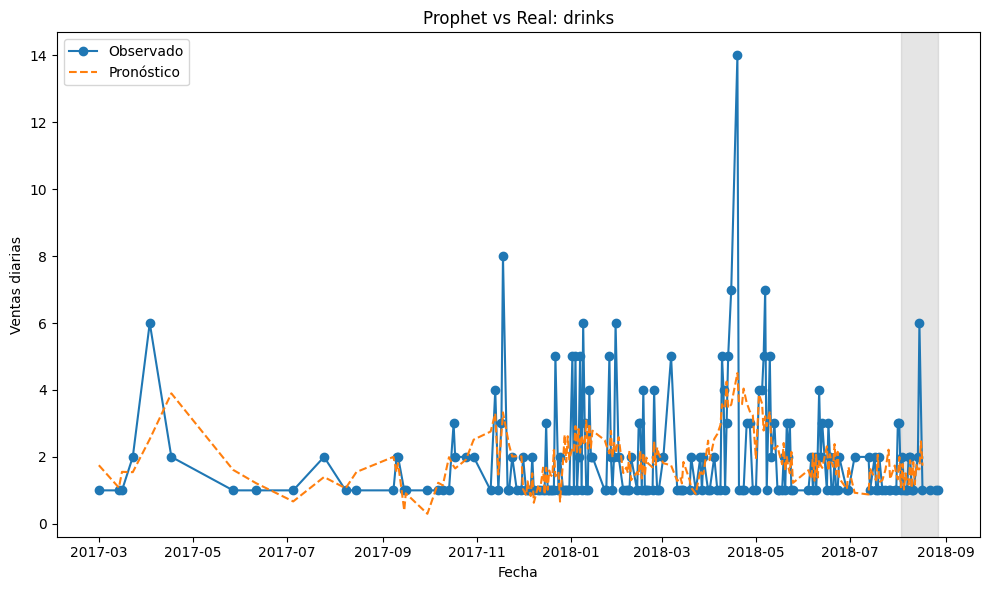

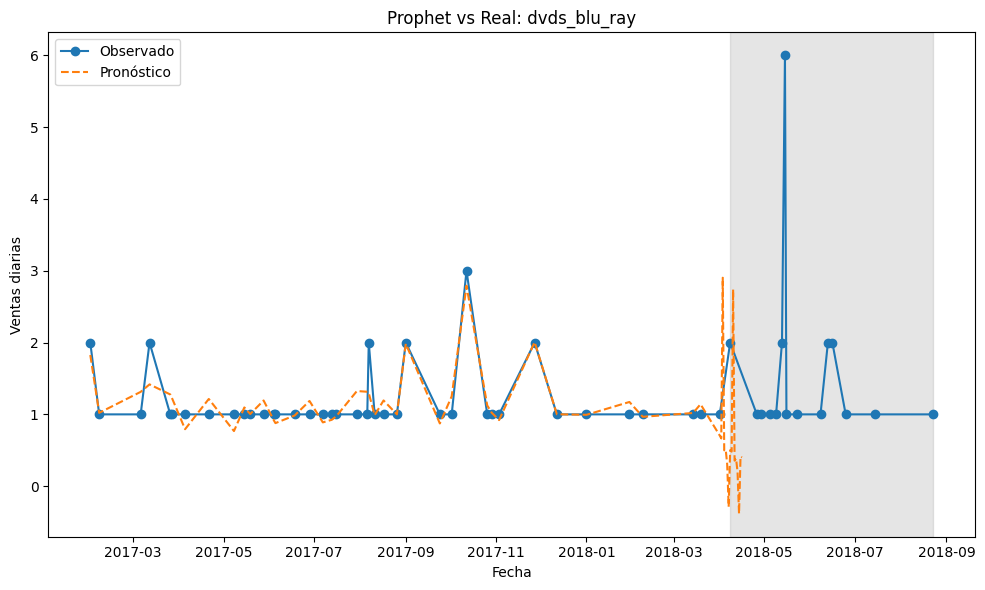

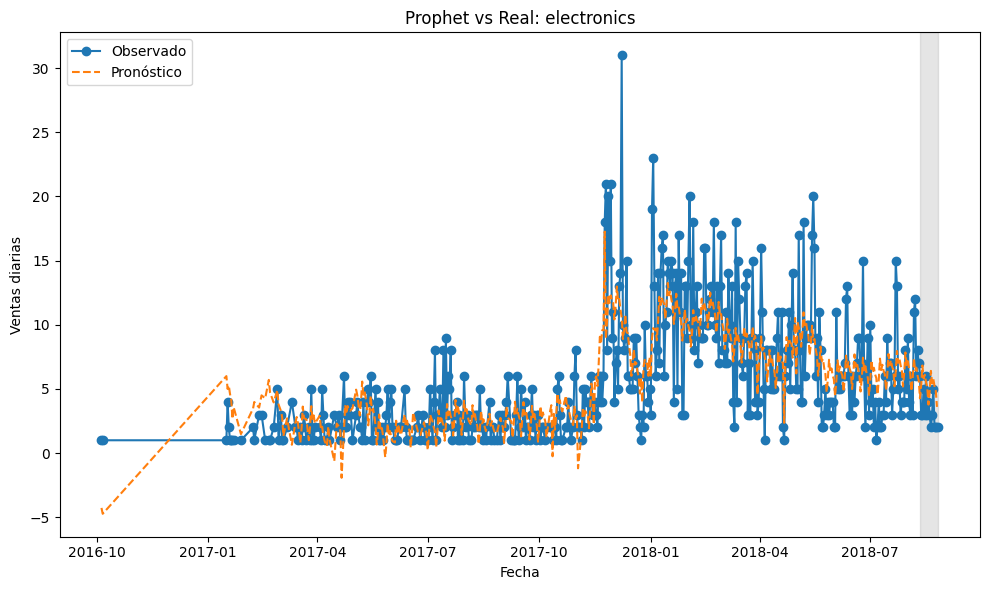

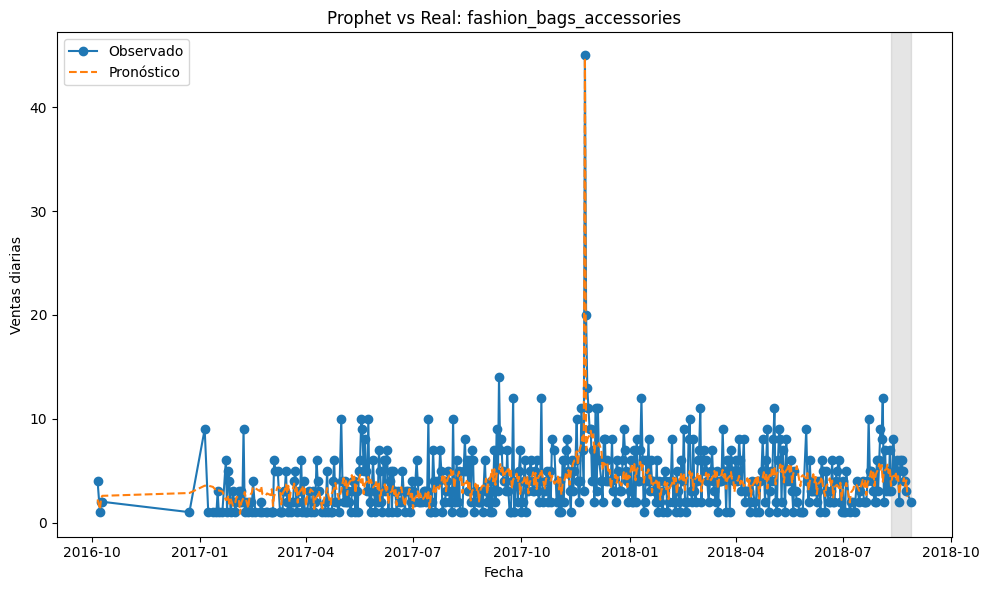

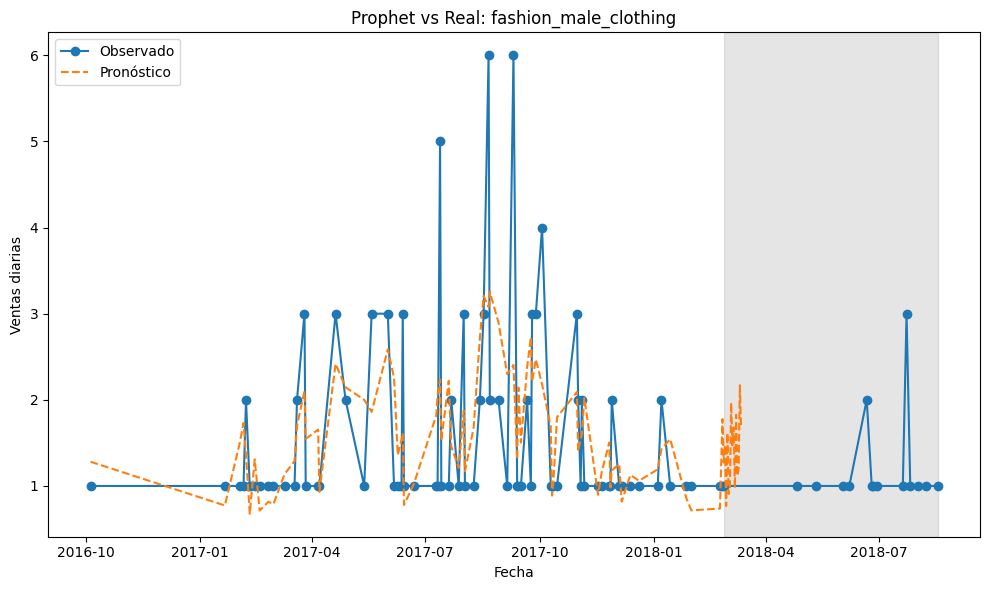

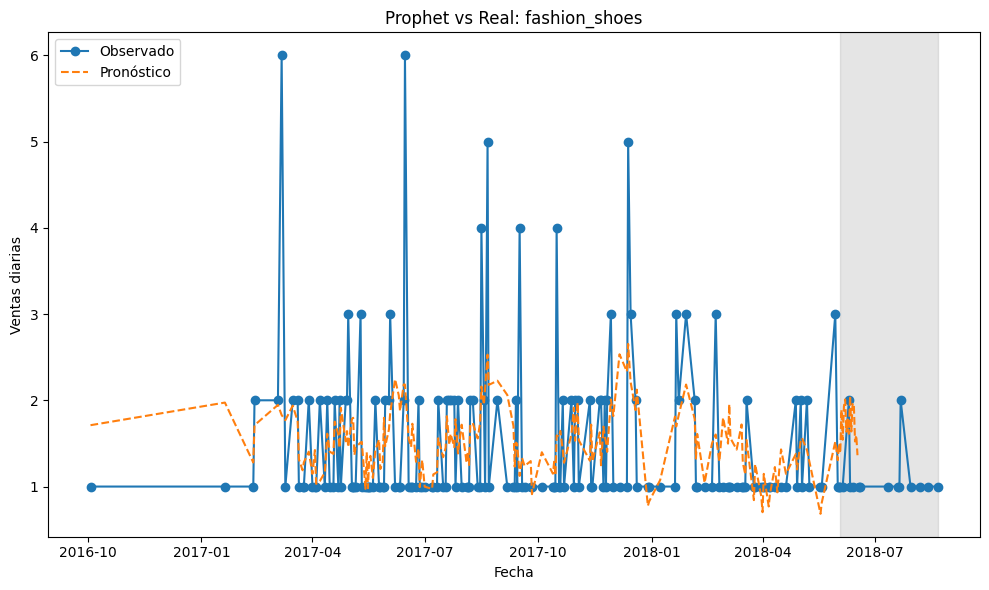

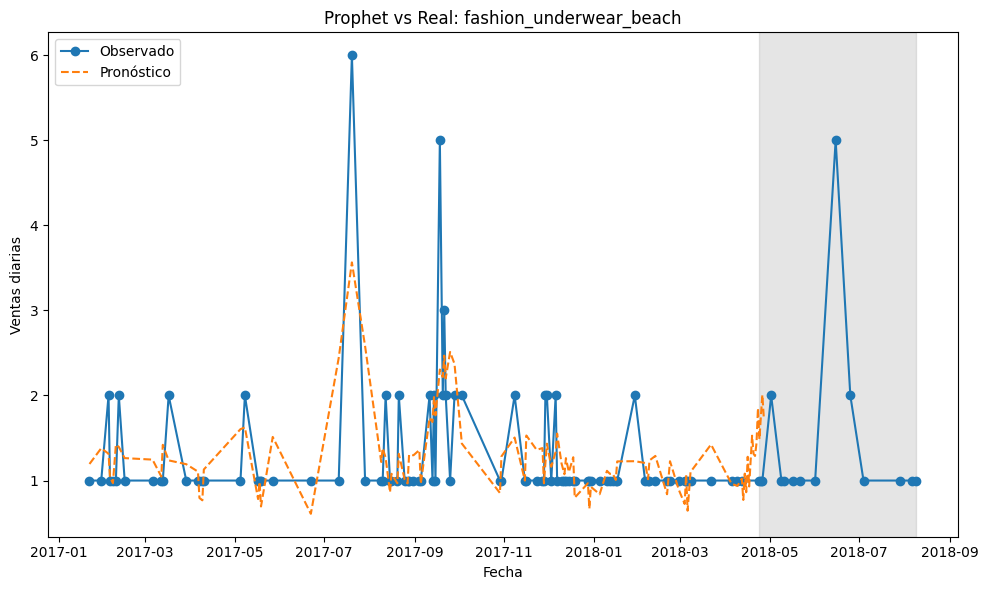

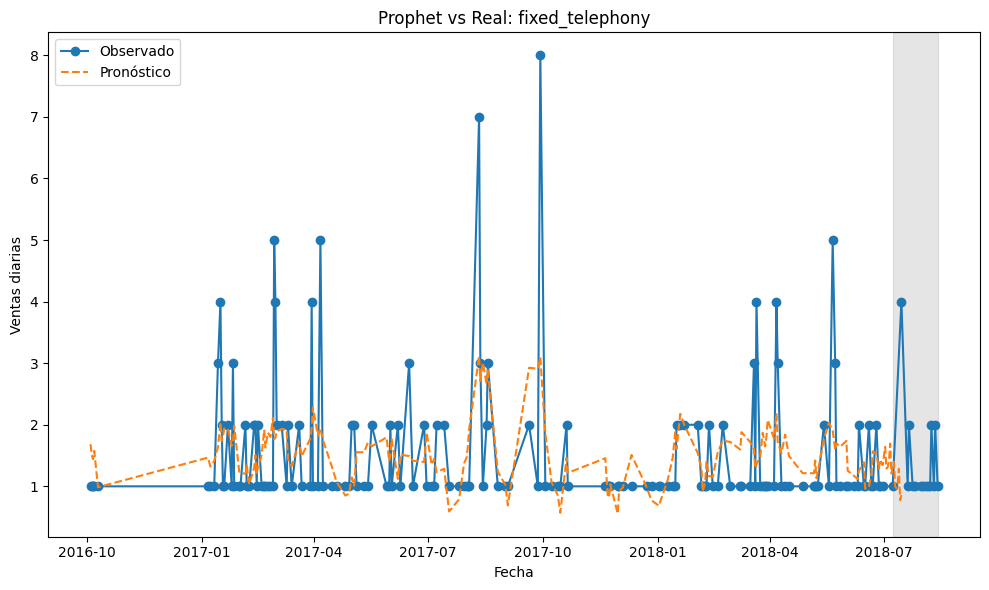

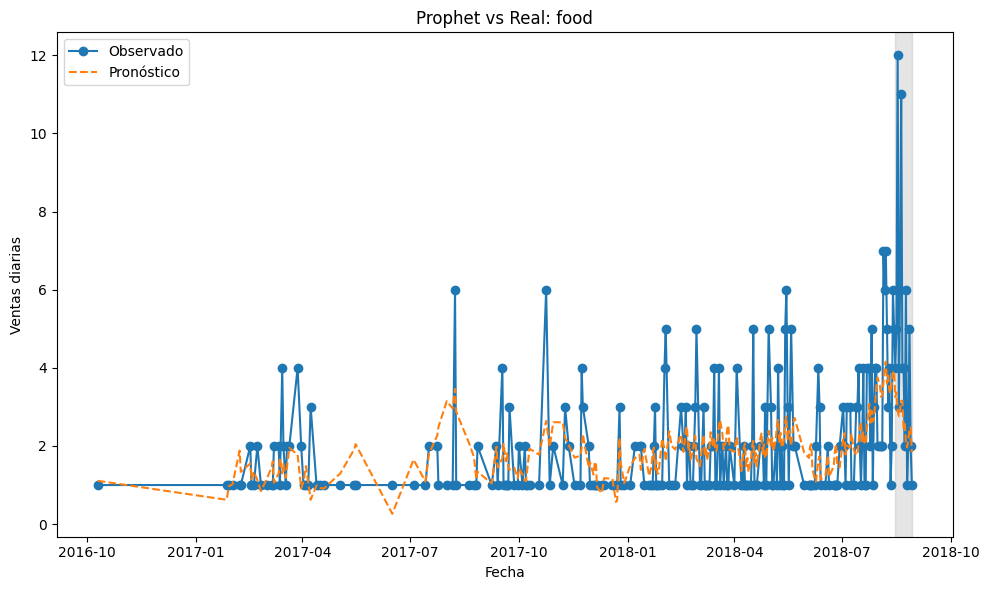

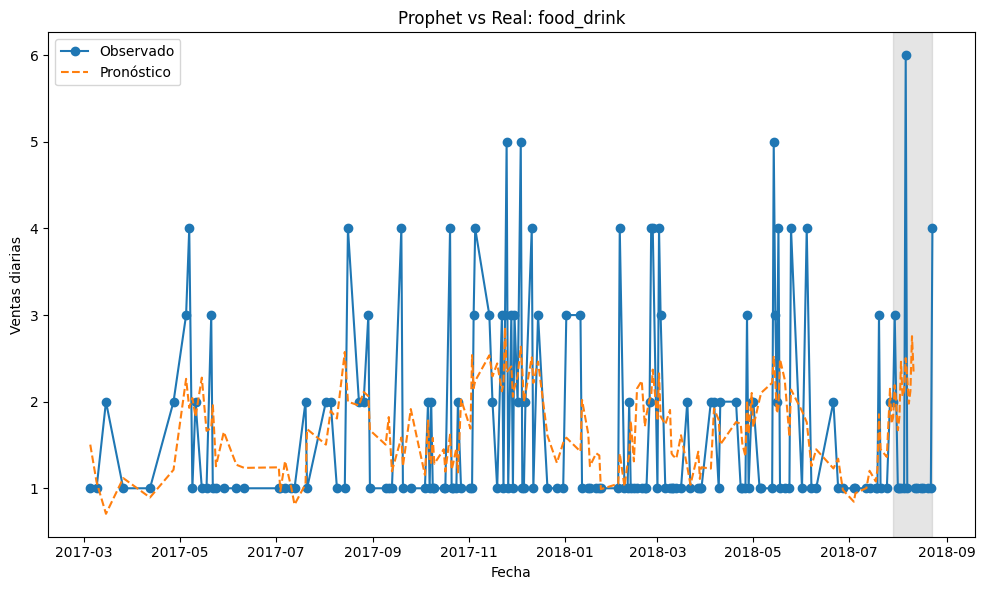

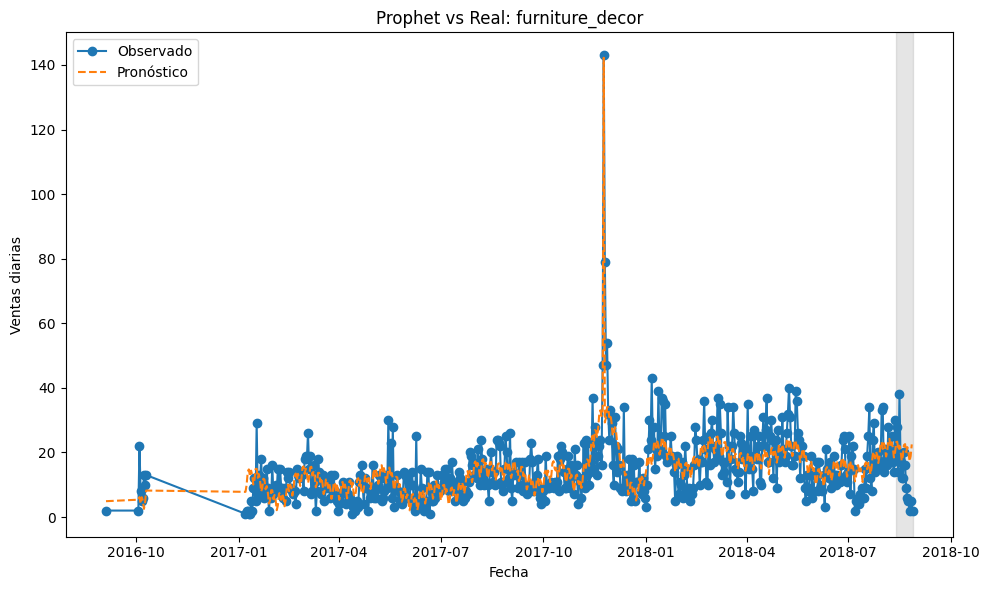

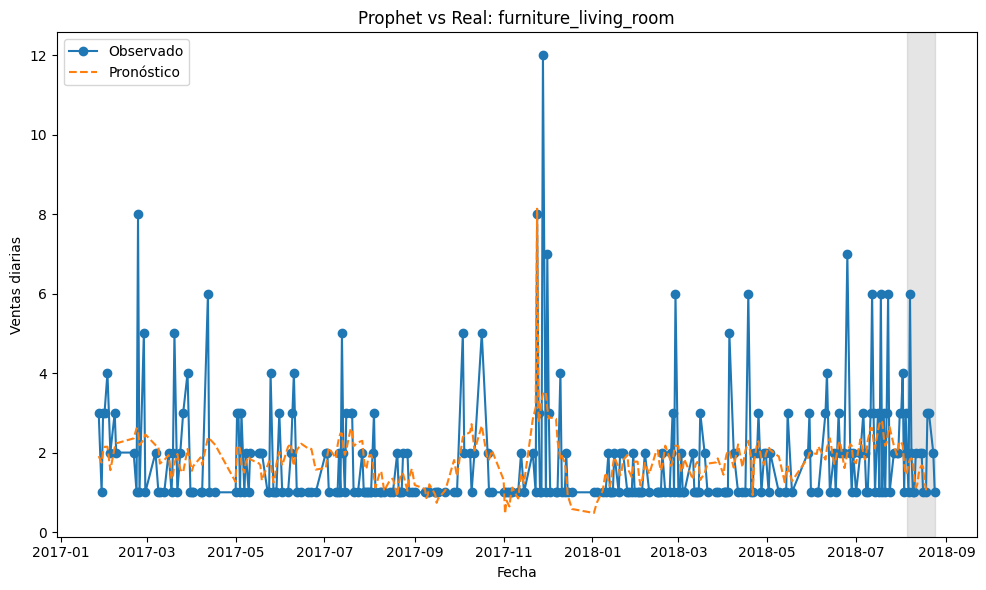

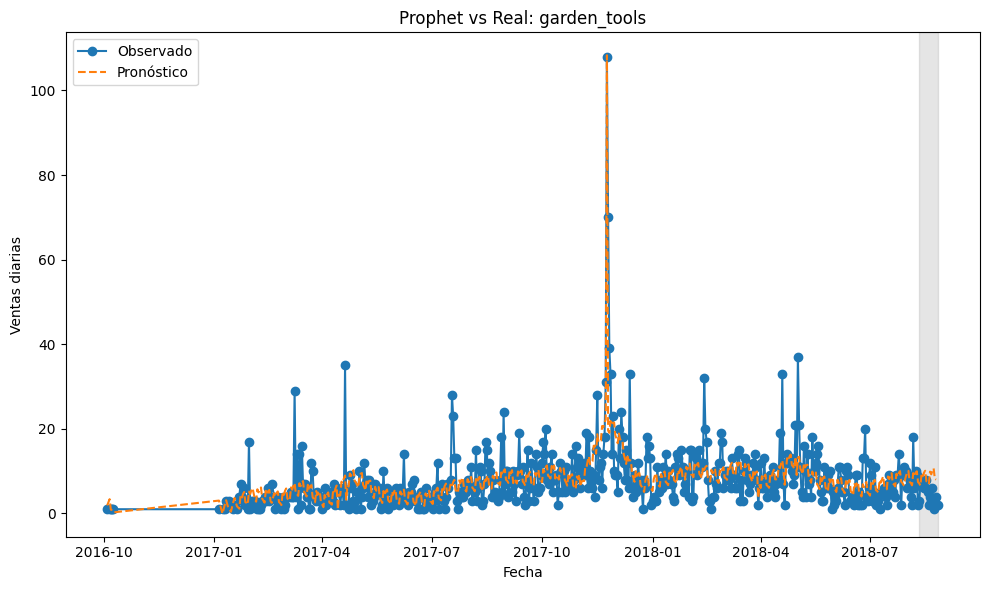

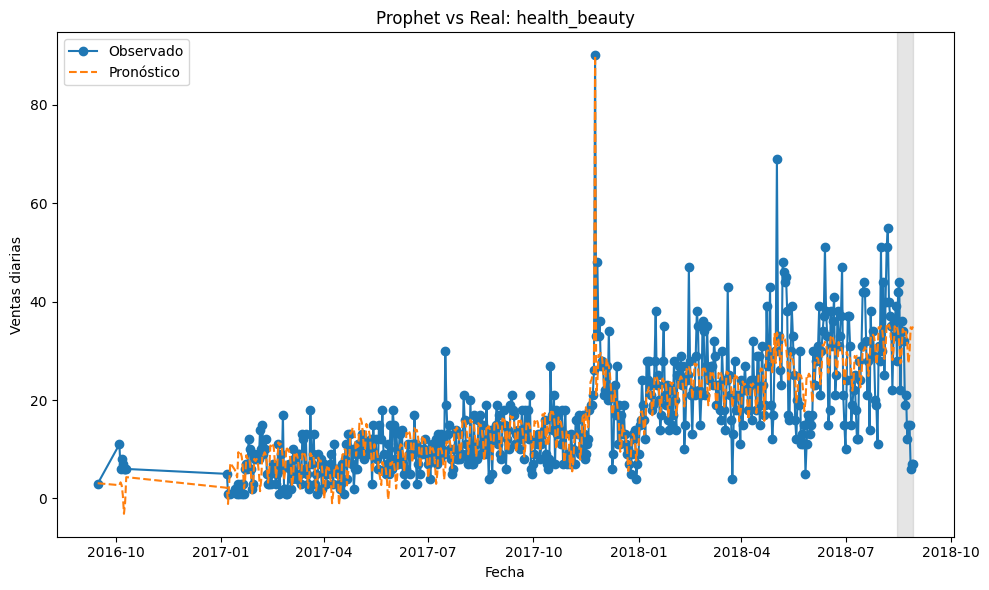

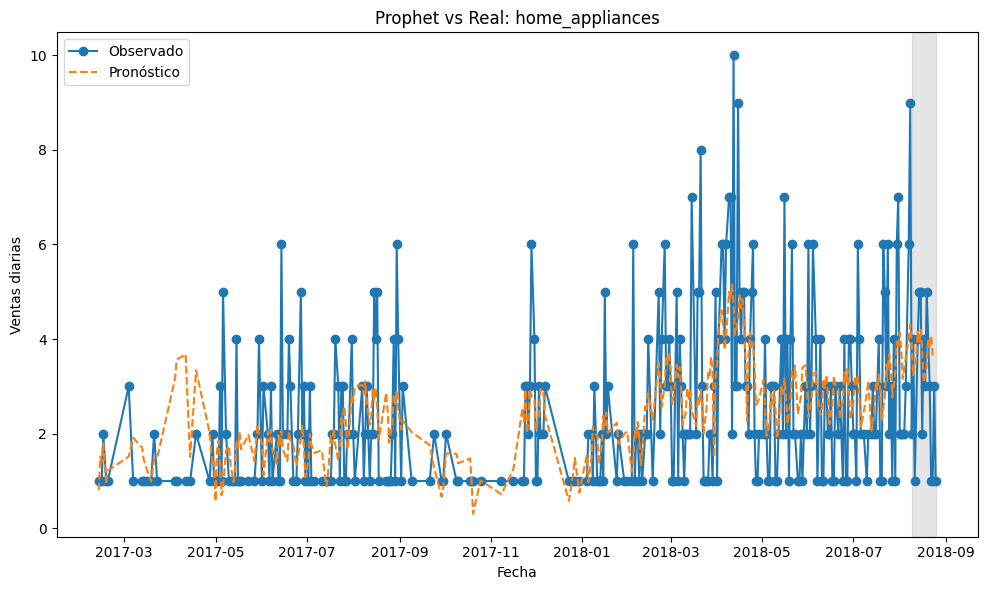

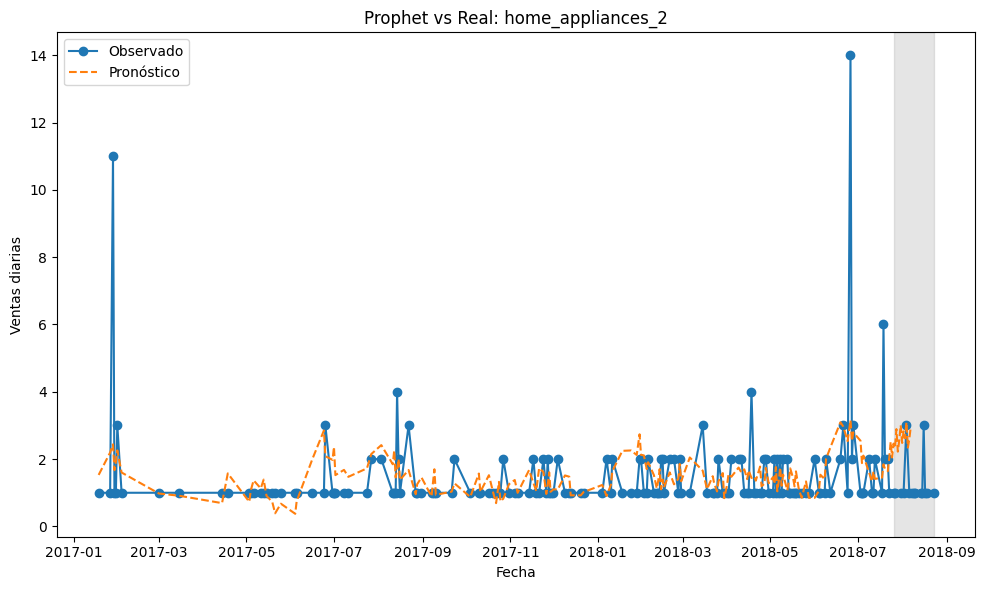

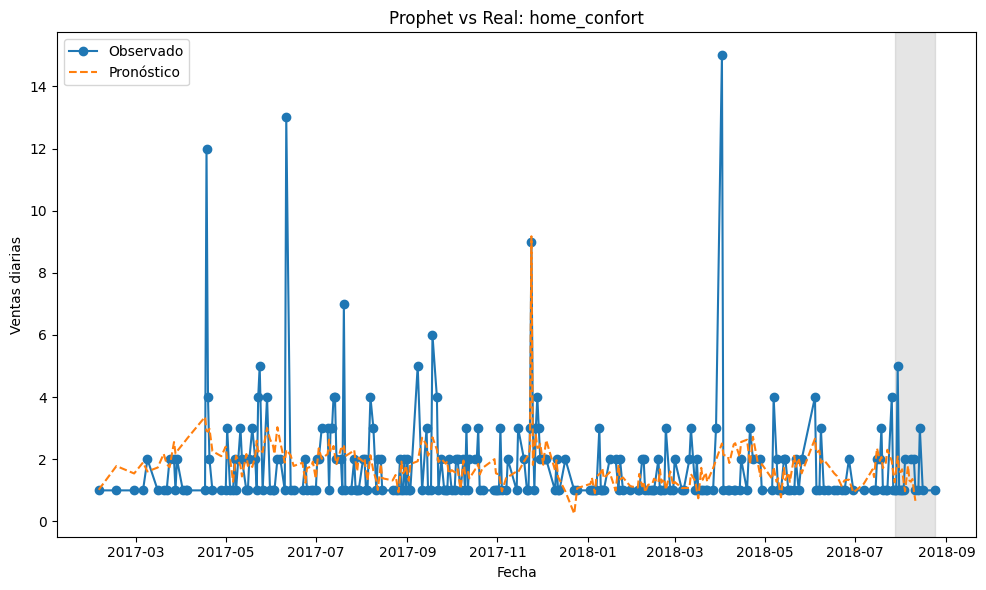

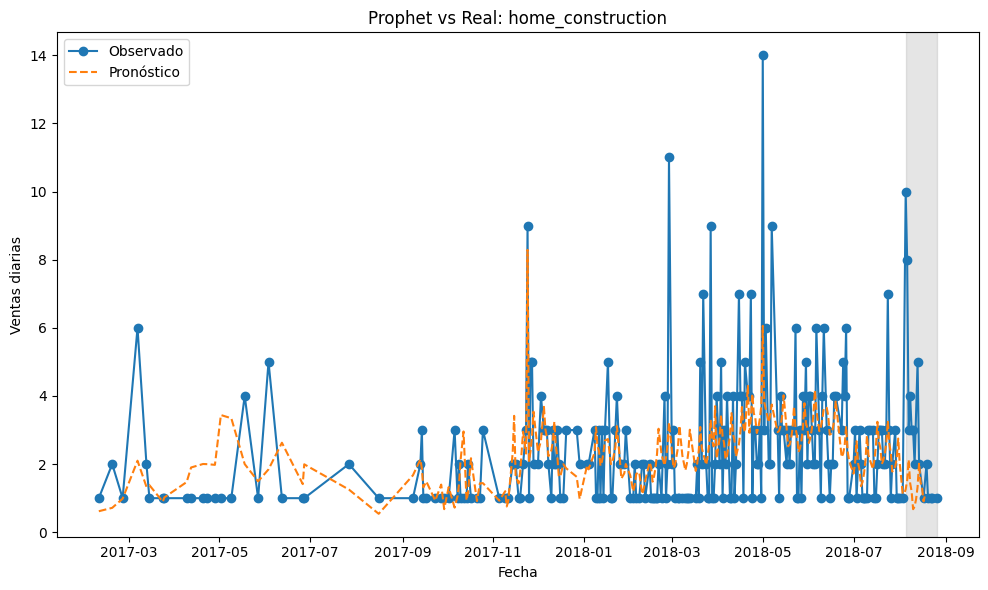

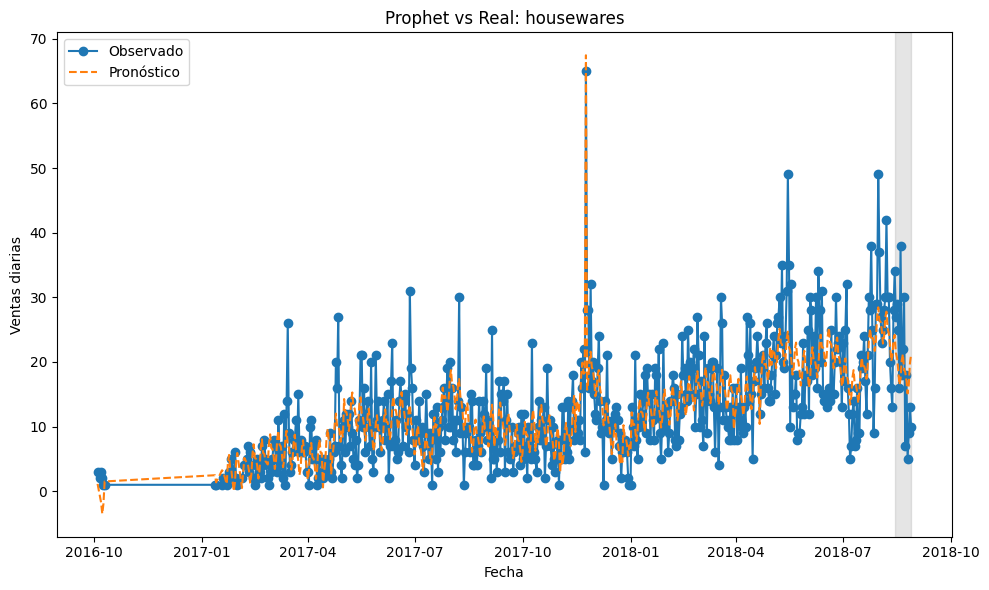

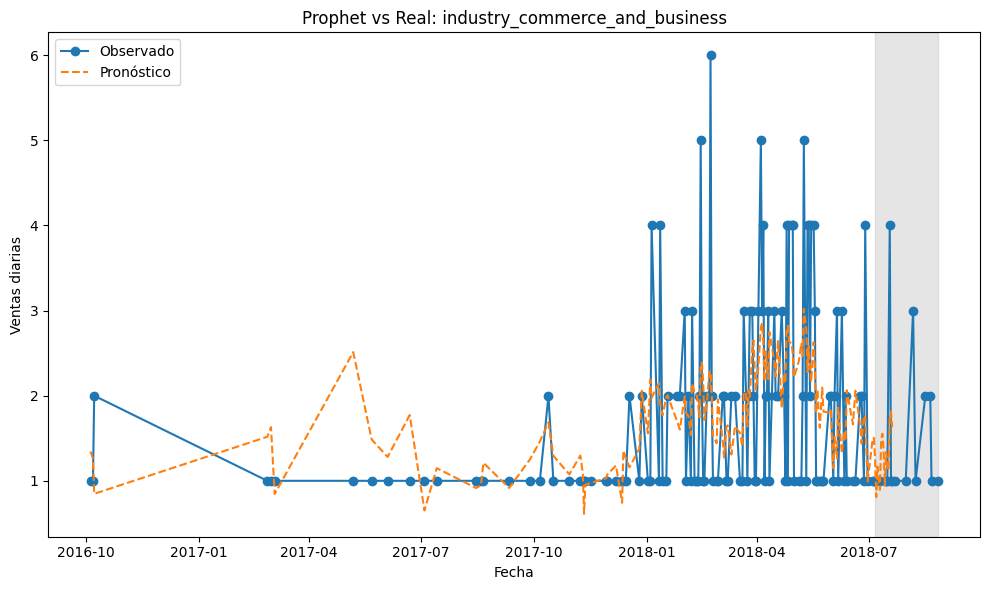

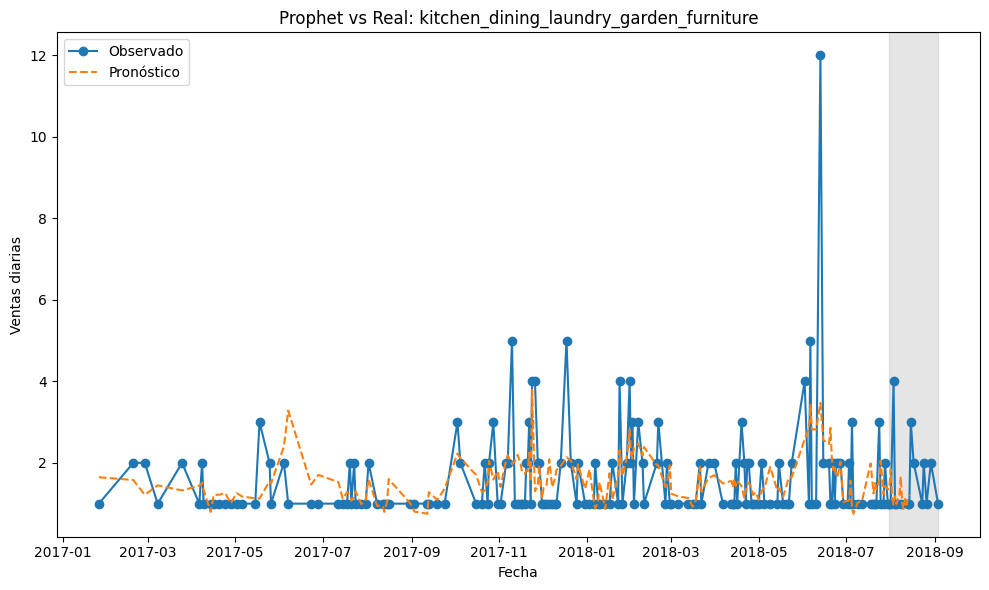

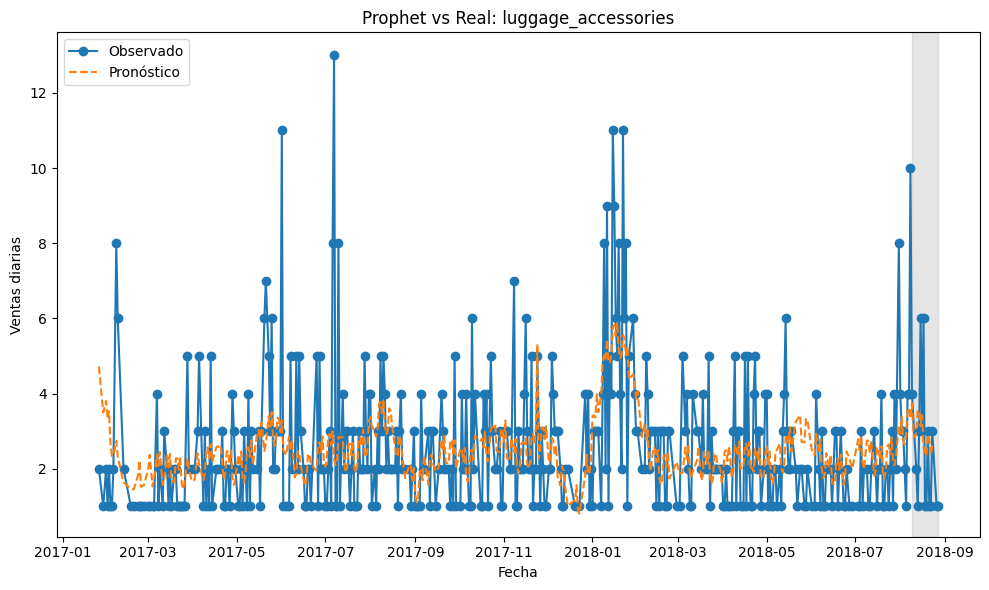

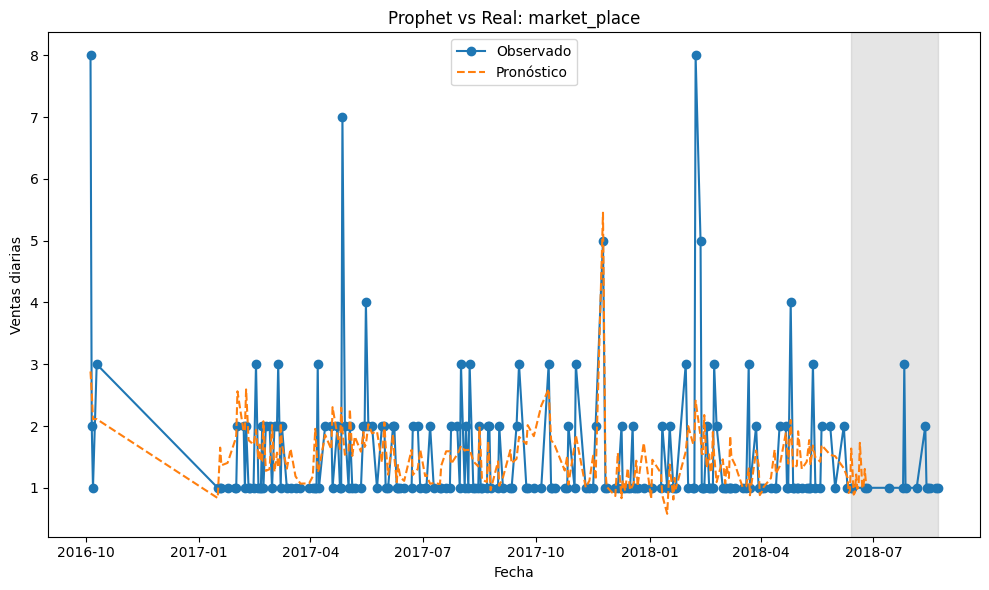

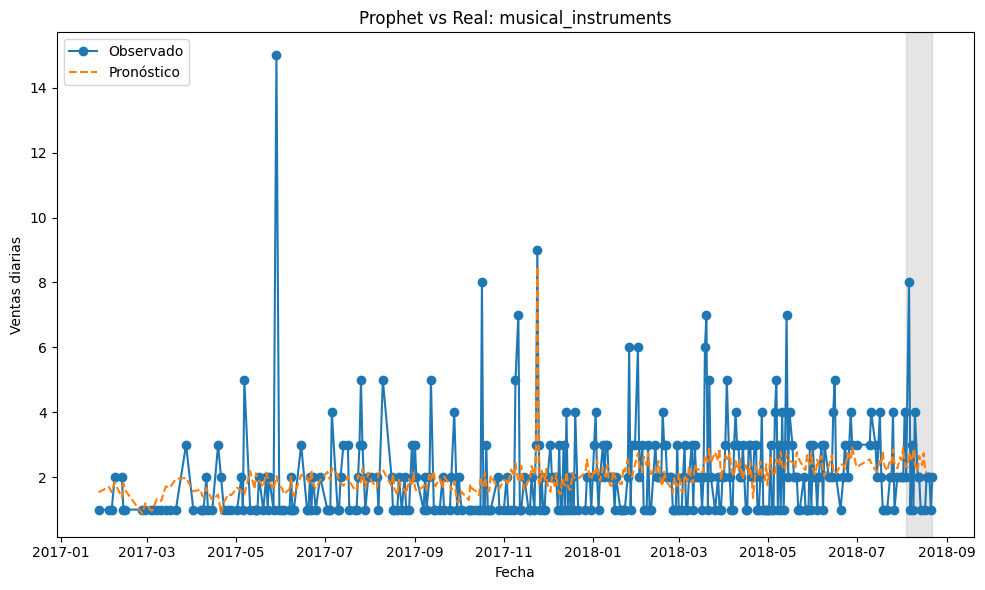

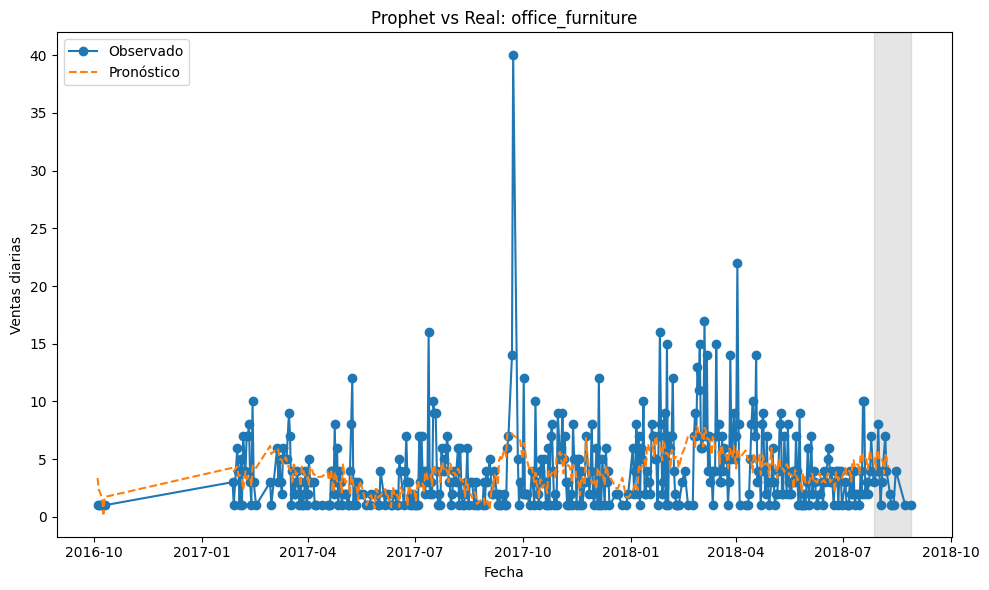

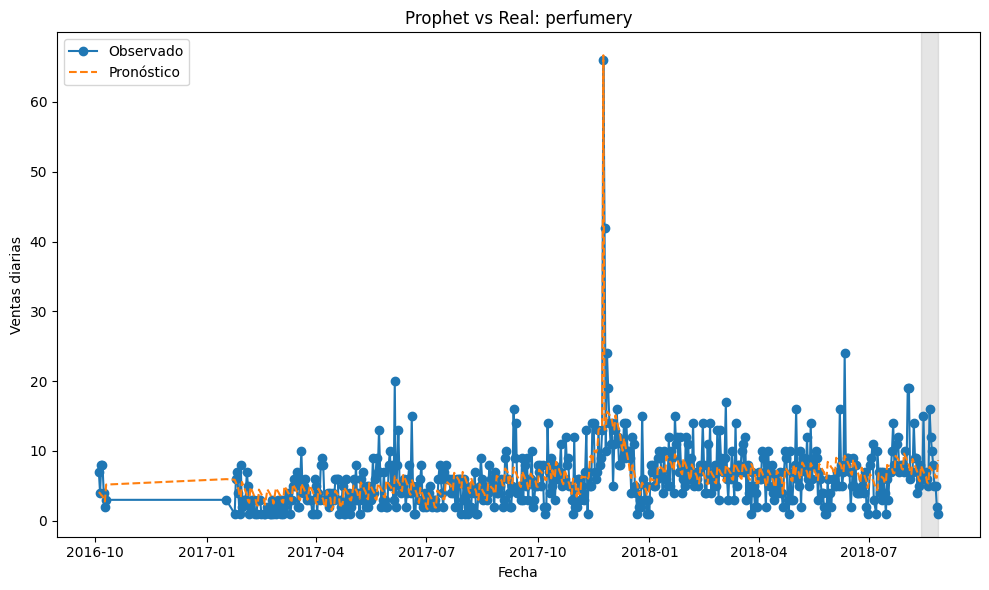

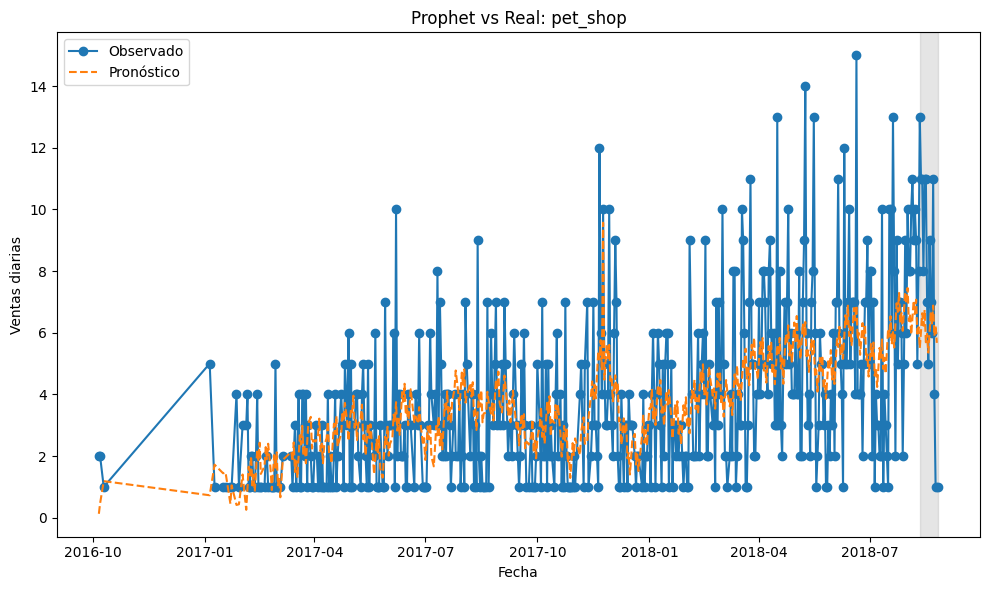

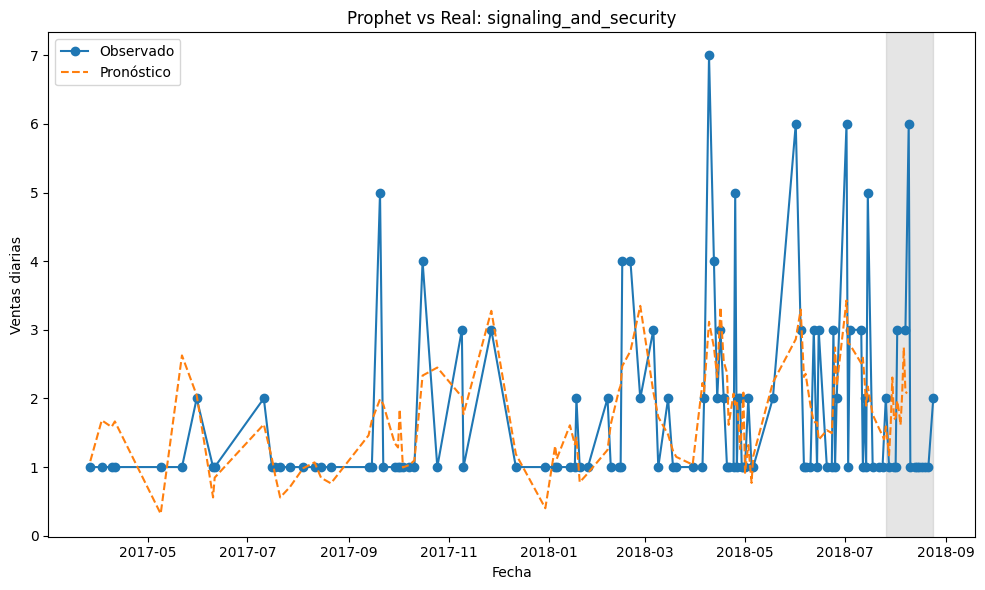

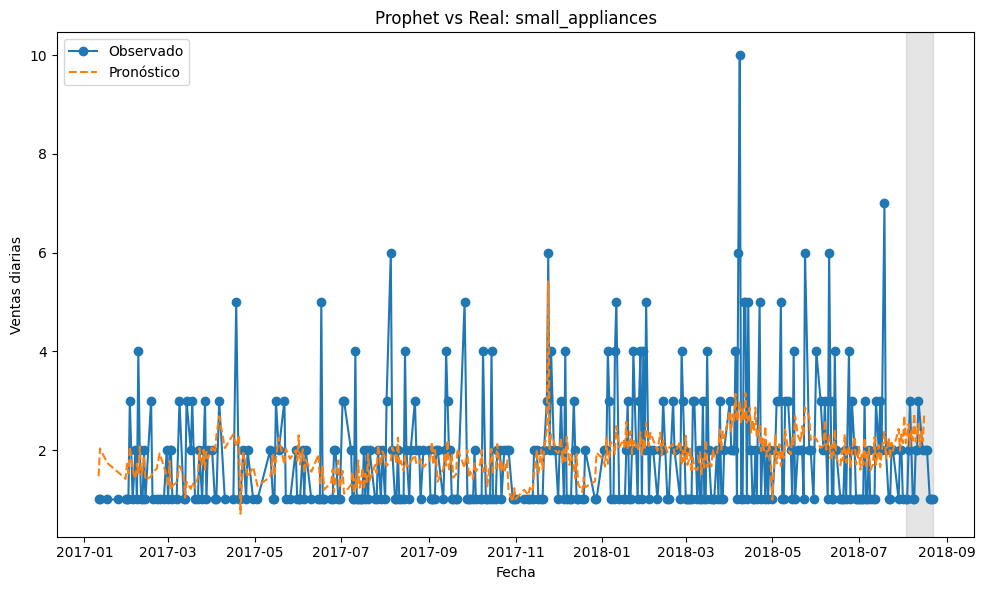

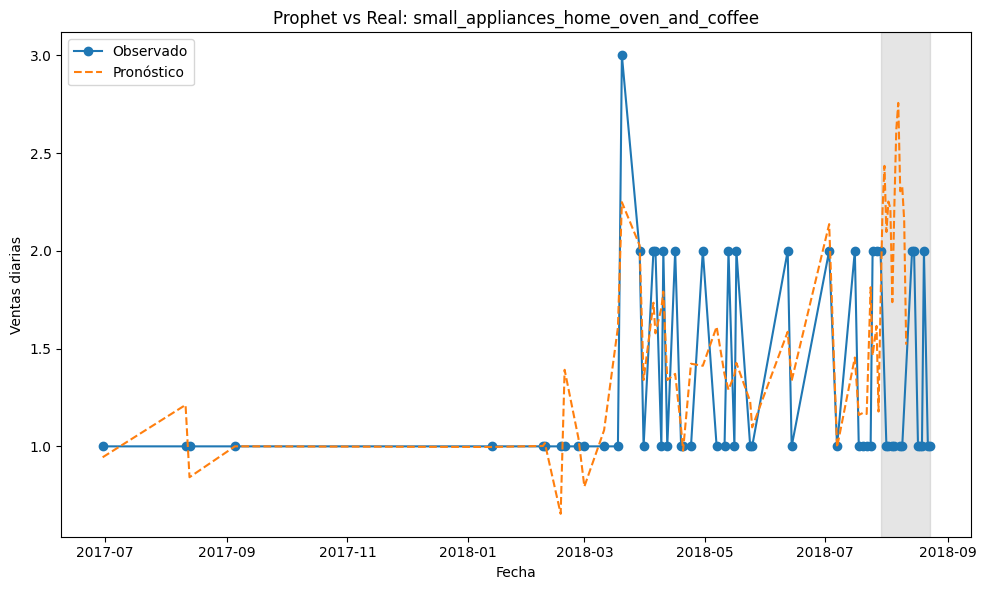

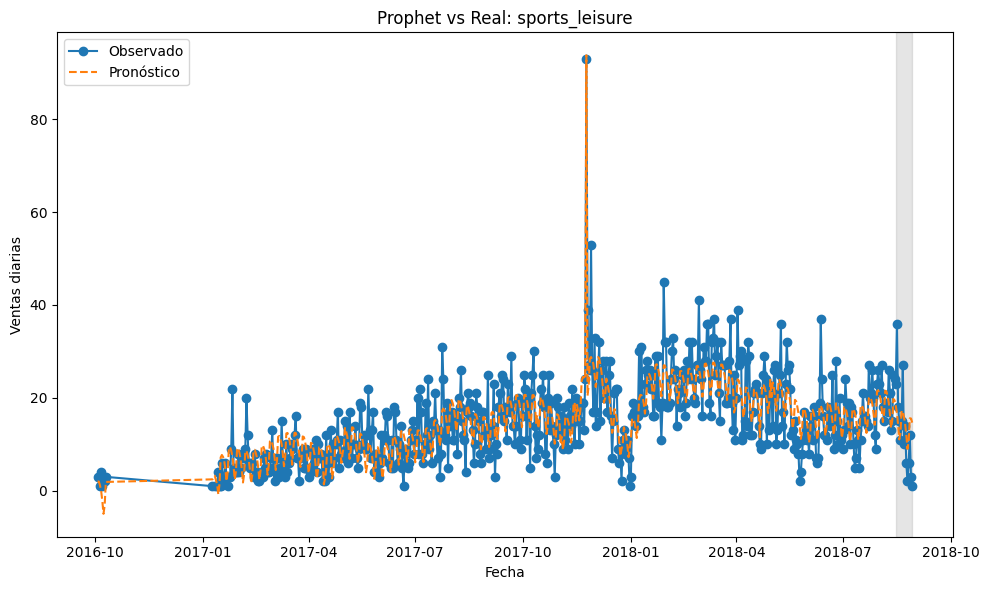

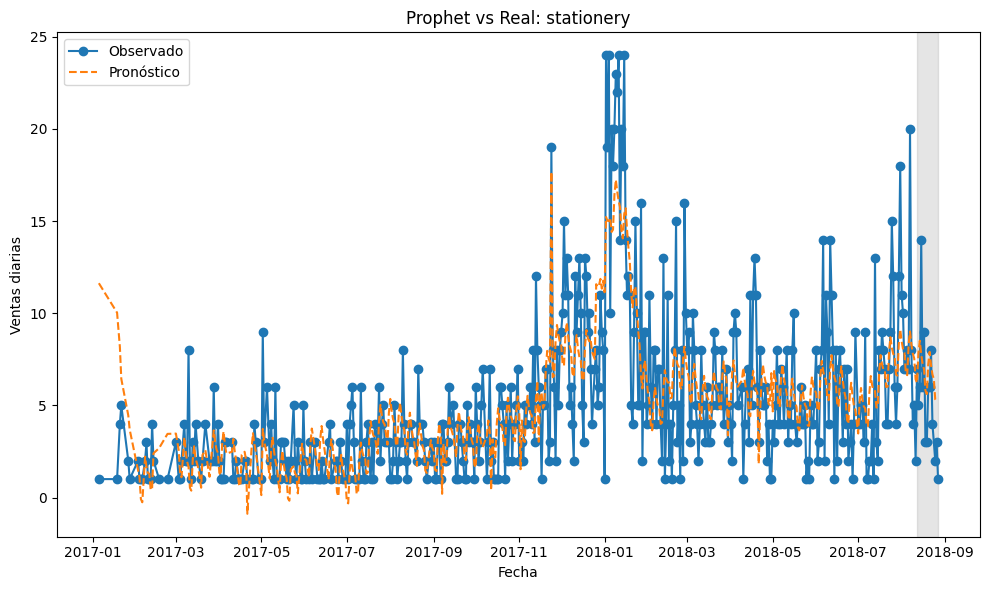

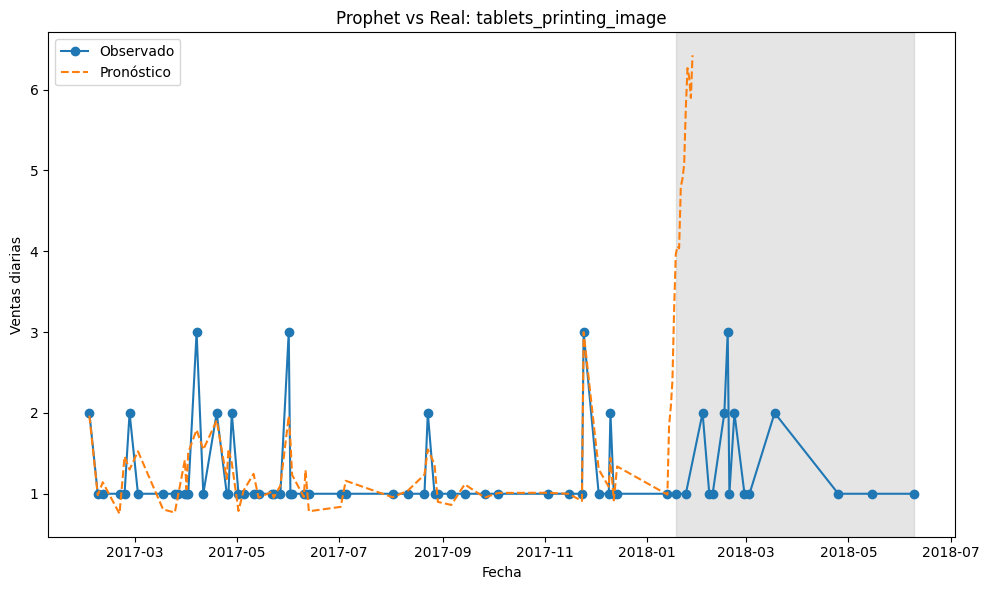

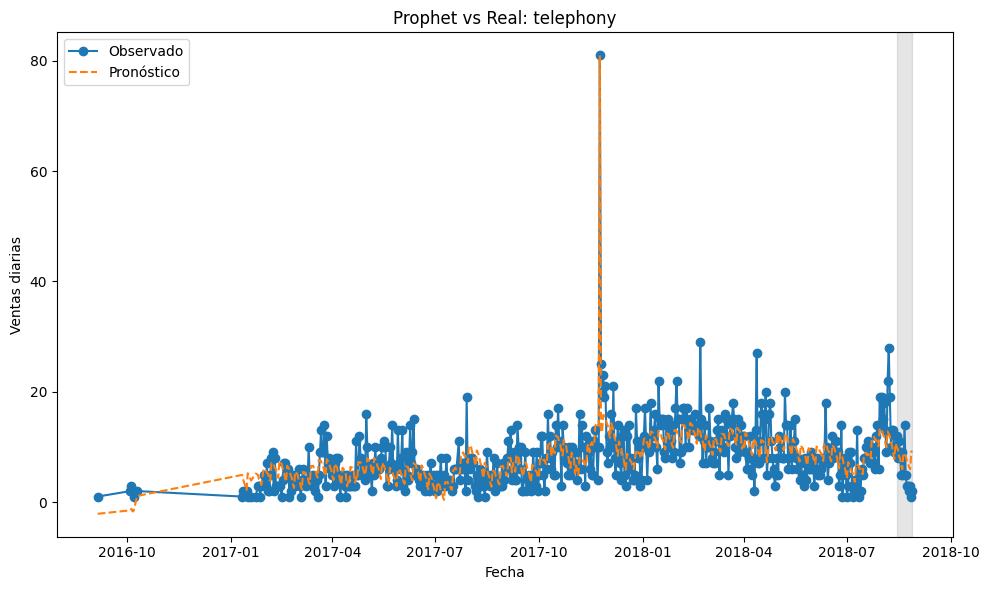

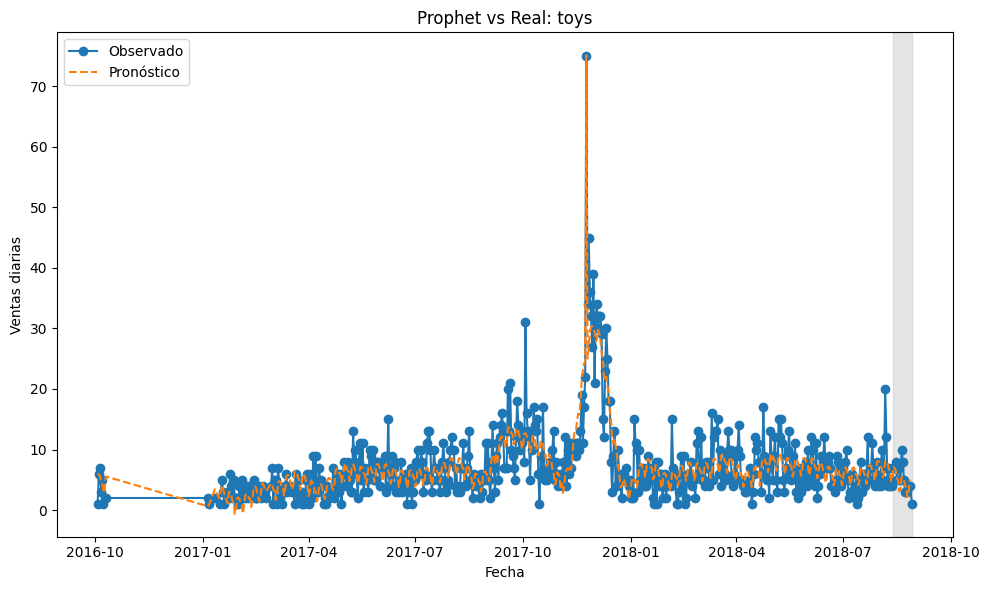

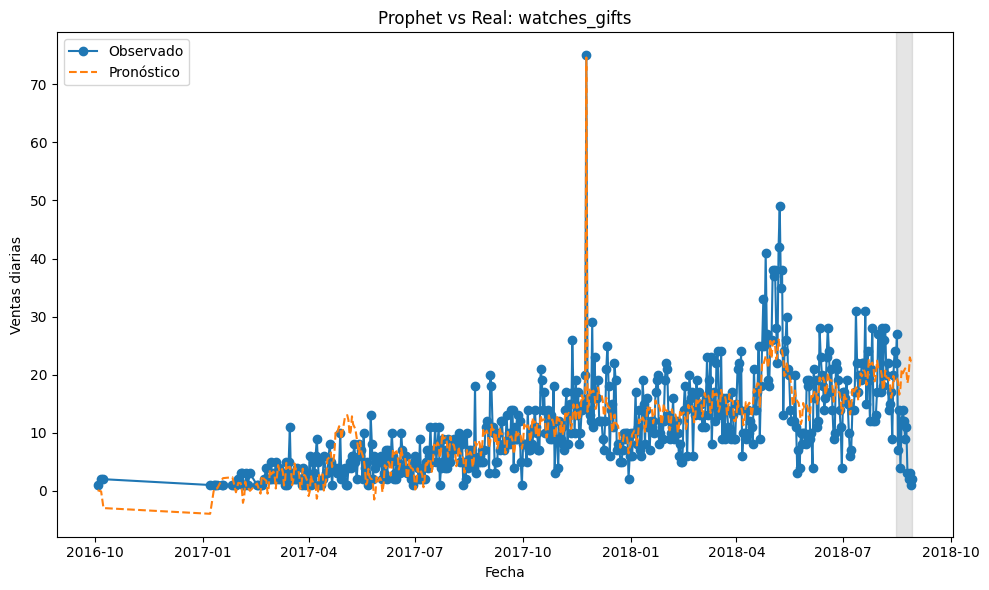

In [ ]:
RAW_CSV = r"C:\Users\fdcontreras\OneDrive - Indra\Universidad\Despliegue de Soluciones Analíticas\Proyecto_Despliegue\Proyecto_Despliegue\data\02_processed\olist_consolidated_dataset.csv"

df = pd.read_csv(RAW_CSV, parse_dates=["order_purchase_timestamp"])
# columna order_date
df["order_date"] = df["order_purchase_timestamp"].dt.date

daily = (
    df.groupby(["product_category_name_english","order_date"])  
      .size().reset_index(name="units_sold")
)

# Celda 2: Selección de categorías válidas
# Criterio: ≥45 días únicos de ventas
rank = (
    daily.groupby("product_category_name_english")["order_date"]
        .nunique()
        .reset_index(name="unique_days")
)
valid_cats = rank[rank["unique_days"] >= 45]["product_category_name_english"].tolist()
print(f"Categorías válidas: {len(valid_cats)}")

# Celda 3: Festivos de Brasil y fechas de Black Friday
years   = sorted(daily["order_date"].apply(lambda d: d.year).unique())
br_hols = holidays.Brazil(years=years)
hols    = pd.DataFrame([{"ds": d, "holiday": "festivo"} for d in br_hols.keys()])

bf_dates = []
for y in years:
    nov = pd.date_range(f"{y}-11-01", f"{y}-11-30", freq="D")
    th  = nov[nov.weekday == 3]
    bf_dates.append((th[3] + pd.Timedelta(days=1)).date())

# Celda 4: Loop de Prophet para todas las categorías
results = []
forecasts = {}  # guardaremos sub, train, test, fcst
for cat in valid_cats:
    sub = (
        daily[daily["product_category_name_english"] == cat]
        .rename(columns={"order_date":"ds","units_sold":"y"})
        [["ds","y"]]
        .sort_values("ds")
        .reset_index(drop=True)
    )
    sub["ds"] = pd.to_datetime(sub["ds"])
    sub["bf"] = sub["ds"].dt.date.isin(bf_dates).astype(int)

    # Split: últimos 15 días test
    train = sub.iloc[:-15].reset_index(drop=True)
    test  = sub.iloc[-15:].reset_index(drop=True)

    # Ajuste de Prophet
    m = Prophet(
        holidays=hols,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    m.add_regressor("bf")
    m.fit(train)

    # Pronóstico
    future = m.make_future_dataframe(periods=15, freq="D")
    future["bf"] = future["ds"].dt.date.isin(bf_dates).astype(int)
    fcst = m.predict(future)
    forecasts[cat] = (sub, train, test, fcst)


    joined = pd.merge(
        test[["ds","y"]],
        fcst[["ds","yhat"]],
        on="ds",
        how="left"
    ).dropna(subset=["yhat"])

    if joined.empty:
        print(f"[{cat}] Sin solapamiento test/predicción, se omite métricas.")
        continue

    # Métricas
    mae  = mean_absolute_error(joined["y"], joined["yhat"])
    rmse = np.sqrt(mean_squared_error(joined["y"], joined["yhat"]))
    mape = np.mean(np.abs((joined["y"] - joined["yhat"]) / joined["y"])) * 100

    results.append({"category":cat, "MAE":mae, "RMSE":rmse, "MAPE (%)":mape})

# Celda 5: Mostrar resultados
res_prophet = pd.DataFrame(results).set_index("category")
display(res_prophet)

# Celda 6: Graficar pronóstico vs real para categorías con métricas
plot_cats = res_prophet.index.tolist()
for cat_plot in plot_cats:
    sub, train, test, fcst = forecasts[cat_plot]
    plt.figure(figsize=(10, 6))
    plt.plot(sub['ds'], sub['y'], label='Observado', marker='o')
    plt.plot(fcst['ds'], fcst['yhat'], label='Pronóstico', linestyle='--')
    plt.axvspan(test['ds'].min(), test['ds'].max(), color='gray', alpha=0.2)
    plt.title(f'Prophet vs Real: {cat_plot}')
    plt.xlabel('Fecha')
    plt.ylabel('Ventas diarias')
    plt.legend()
    plt.tight_layout()
    plt.show()